# Evaluating the Generalizability of Heart Disease Prediction Models Across Heterogeneous Populations

**Student Names:**  
- Hiba Amanulla S23108227
- Ghala AlGhamdi S23108212

**Course / Supervisor:** Dr Passent Elkafrawy



---

## Project Overview

This project investigates how well machine learning models for heart disease prediction generalize across different populations. The study uses the UCI heart disease datasets from four cohorts: **Cleveland, Hungary, Switzerland, and VA Long Beach**. Many previous studies evaluate models using only internal validation, where the model is trained and tested on the same dataset. Although this often produces strong results, it does not show whether the model can perform well on a different population.

The main goal of this project is to test **cross-cohort generalization**. In this approach, a model is trained on one cohort and tested on the other three cohorts. This provides a more realistic measure of model robustness and external validity. The notebook includes data loading, cleaning, exploratory inspection, preprocessing, model training, external validation, internal validation, and results comparison.

---

## Research Logic

The key idea behind this notebook is that data from different populations may follow different distributions. A model that performs well on one cohort may not perform equally well on another cohort. Therefore, evaluating only internal performance may overestimate how useful the model really is in real-world settings. To address this issue, this notebook compares internal validation results with external cross-cohort results.

---

## Workflow

1. Upload and load the datasets  
2. Clean and validate the data  
3. Inspect missing values, duplicates, and unusual values  
4. Prepare features and target labels  
5. Build preprocessing and machine learning pipelines  
6. Train on one cohort and test on the other three  
7. Run internal validation for comparison  
8. Save and summarize the results

## Step 0: Import the Required Libraries

This step imports all required Python libraries for data processing, visualization, and machine learning.

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

## Step 1: Upload the Dataset Files

In this step, the four heart disease datasets are uploaded for analysis.

We upload the four heart disease cohort files:

- `processed.cleveland.data`
- `processed.hungarian.data`
- `processed.switzerland.data`
- `processed.va.data`

This step is necessary because the notebook needs access to the raw data files before they can be loaded into pandas DataFrames for cleaning and analysis.

In [ ]:
# Upload dataset files

from google.colab import files

uploaded = files.upload()

Saving processed.cleveland.data to processed.cleveland (2).data
Saving processed.hungarian.data to processed.hungarian (2).data
Saving processed.switzerland.data to processed.switzerland (2).data
Saving processed.va.data to processed.va (2).data


## Step 2: Define Dataset Structure

This step defines column names, feature types, and valid category values for the dataset.

### What This Code Is Doing

This code defines the structure and rules of the dataset for later processing.

- **`columns`**  
  Defines the column names assigned to the dataset.

- **`categorical_cols`**  
  Identifies categorical features (discrete values).

- **`numeric_cols`**  
  Identifies numerical features (continuous values).

- **`feature_cols`**  
  Combines all input features used for modeling.

- **`target_col`**  
  Defines the target variable to be predicted.

- **`valid_categories`**  
  Specifies valid values for categorical features; invalid values are treated as missing.

In [ ]:
columns = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"
]

categorical_cols = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]
numeric_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]

feature_cols = numeric_cols + categorical_cols
target_col = "target_binary"

valid_categories = {
    "sex": [0, 1],
    "cp": [1, 2, 3, 4],
    "fbs": [0, 1],
    "restecg": [0, 1, 2],
    "exang": [0, 1],
    "slope": [1, 2, 3],
    "ca": [0, 1, 2, 3],
    "thal": [3, 6, 7],
    "target": [0, 1, 2, 3, 4]
}

## Step 3: Load and Prepare the Four Cohort Datasets

This step loads each dataset, handles missing values, and adds a cohort label.

### What This Code Is Doing

This code loads the datasets and prepares them for analysis.

- **`pd.read_csv()`**  
  Loads each dataset into a pandas DataFrame.
  - `header=None` no column headers in the file  
  - `names=columns` assigns column names
  - `na_values="?"` treats "?" as missing values

- **Add `cohort` column**  
  Adds a label to identify the dataset source.

- **Create `datasets` dictionary**  
  Stores all datasets for easy access.

- **Print dataset shapes**  
  Displays the number of rows and columns for each dataset.

In [ ]:
cleveland = pd.read_csv("processed.cleveland.data", header=None, names=columns, na_values="?")
hungary = pd.read_csv("processed.hungarian.data", header=None, names=columns, na_values="?")
switzerland = pd.read_csv("processed.switzerland.data", header=None, names=columns, na_values="?")
va = pd.read_csv("processed.va.data", header=None, names=columns, na_values="?")

cleveland["cohort"] = "cleveland"
hungary["cohort"] = "hungary"
switzerland["cohort"] = "switzerland"
va["cohort"] = "va"

datasets = {
    "cleveland": cleveland,
    "hungary": hungary,
    "switzerland": switzerland,
    "va": va
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

cleveland: (303, 15)
hungary: (294, 15)
switzerland: (123, 15)
va: (200, 15)


## Step 4: Perform an Initial Inspection of the Data

This step examines the structure, data types, and missing values of each dataset to understand data quality before cleaning.

In [ ]:
from IPython.display import display

for name, df in datasets.items():
    print(f"\n ====================== {name.upper()} DATASET OVERVIEW ======================")

    # Shape
    shape_df = pd.DataFrame({
        "Rows": [df.shape[0]],
        "Columns": [df.shape[1]]
    })
    print("\nDataset Shape")
    display(shape_df)

    # First 5 rows
    print("\nFirst 5 Rows")
    display(df.head())

    # Data types
    dtype_df = df.dtypes.reset_index()
    dtype_df.columns = ["Column", "Data Type"]
    print("\nData Types")
    display(dtype_df)

    # Missing values
    missing_df = df.isna().sum().reset_index()
    missing_df.columns = ["Column", "Missing Values"]
    print("\nMissing Values")
    display(missing_df)


 ====================== CLEVELAND DATASET OVERVIEW ======================

Dataset Shape


,Rows,Columns
0,303,15



First 5 Rows


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,cohort
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,cleveland
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2,cleveland
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,cleveland
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,cleveland
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,cleveland



Data Types


...

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,cohort
0,63,1,4,140.0,260.0,0.0,1,112.0,1.0,3.0,2.0,NaN,NaN,2,va
1,44,1,4,130.0,209.0,0.0,1,127.0,0.0,0.0,NaN,NaN,NaN,0,va
2,60,1,4,132.0,218.0,0.0,1,140.0,1.0,1.5,3.0,NaN,NaN,2,va
3,55,1,4,142.0,228.0,0.0,1,149.0,1.0,2.5,1.0,NaN,NaN,1,va
4,66,1,3,110.0,213.0,1.0,2,99.0,1.0,1.3,2.0,NaN,NaN,0,va



Data Types


,Column,Data Type
0,age,int64
1,sex,int64
2,cp,int64
3,trestbps,float64
4,chol,float64
5,fbs,float64
6,restecg,int64
7,thalach,float64
8,exang,float64
9,oldpeak,float64



Missing Values


,Column,Missing Values
0,age,0
1,sex,0
2,cp,0
3,trestbps,56
4,chol,7
5,fbs,7
6,restecg,0
7,thalach,53
8,exang,53
9,oldpeak,56


**Cleveland:**

The dataset is well-structured with minimal missing values, indicating good data quality.

**Hungary:**

This dataset contains more missing values, especially in several clinical variables, which will require careful handling.

**Switzerland:**

This dataset has a smaller size and significant missing values, which may impact model performance.

**VA:**

This dataset shows high levels of missing data, making preprocessing and imputation essential.

## Step 5: Create Data Cleaning Functions

This step defines reusable functions to clean all four datasets consistently.

### What This Code Is Doing
- **`convert_to_numeric(df)`**  
  Converts values to numeric form and replaces invalid entries with **NaN**.

- **`fix_invalid_categories(df)`**  
  Replaces invalid category values with **NaN**.

- **`fix_impossible_numeric_values(df)`**  
  Replaces unrealistic numeric values with **NaN**.

- **`add_binary_target(df)`**  
  Converts the original `target` variable (0–4) into a **binary variable** (`target_binary`), where  
  `0 = no disease` and `1 = disease present`.

- **`cap_outliers_iqr(df, numeric_cols)`**  
  Caps extreme numeric values using the IQR method.

In [ ]:
def convert_to_numeric(df):
    df = df.copy()
    for col in columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    return df

def fix_invalid_categories(df):
    df = df.copy()
    for col, allowed in valid_categories.items():
        invalid_mask = df[col].notna() & (~df[col].isin(allowed))
        df.loc[invalid_mask, col] = np.nan
    return df

def fix_impossible_numeric_values(df):
    df = df.copy()

    impossible_rules = {
        "age": (1, 120),
        "trestbps": (1, 300),
        "chol": (1, 1000),
        "thalach": (1, 250),
        "oldpeak": (0, 10)
    }

    for col, (low, high) in impossible_rules.items():
        invalid_mask = df[col].notna() & ((df[col] < low) | (df[col] > high))
        df.loc[invalid_mask, col] = np.nan

    return df

def add_binary_target(df):
    df = df.copy()
    df["target_binary"] = np.where(df["target"].isna(), np.nan, (df["target"] > 0).astype(int))
    return df

def cap_outliers_iqr(df, numeric_cols):
    df = df.copy()

    for col in numeric_cols:
        if col in df.columns:
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1

            lower = Q1 - 1.5 * IQR
            upper = Q3 + 1.5 * IQR

            df[col] = df[col].clip(lower=lower, upper=upper)

    return df

## Step 6: Clean All Four Cohort Datasets

This step applies the same cleaning process to all four cohorts to ensure consistency before modeling.

### What This Code Is Doing

This code defines the function **`clean_dataset(df, name)`**, which applies all cleaning steps to a dataset and displays summary information.

- converts values to numeric format
- removes duplicate rows
- replaces invalid categorical values with NaN
- replaces impossible numeric values with NaN
- creates target_binary
- caps outliers using the IQR method
- drops weak or high-missing columns
- keeps the final selected features
- displays missing values, class distribution, and final shape

The removed columns were `ca`, `chol`, `thal`, `fbs`, `trestbps`, `restecg`, and `slope` due to missing values, instability across cohorts, or weaker usefulness for the final model.

In [ ]:
from IPython.display import display

def clean_dataset(df, name):
    df = df.copy()

    print(f"\n================ CLEANING {name.upper()} ================")

    # Add cohort label
    df["cohort"] = name

    # Convert all columns to numeric where possible
    df = convert_to_numeric(df)

    # Count duplicates before removing
    duplicate_count = df.duplicated().sum()
    display(pd.DataFrame({"Duplicate Rows": [duplicate_count]}))

    # Remove duplicates
    df = df.drop_duplicates().reset_index(drop=True)

    # Fix invalid categorical values
    df = fix_invalid_categories(df)

    # Fix impossible numeric values
    df = fix_impossible_numeric_values(df)

    # Create binary target
    df = add_binary_target(df)

    # Remove rows where target_binary is missing
    df = df.dropna(subset=["target_binary"]).reset_index(drop=True)

    # Cap outliers before dropping columns
    numeric_for_capping = ["age", "trestbps", "chol", "thalach", "oldpeak"]
    df = cap_outliers_iqr(df, numeric_for_capping)

    # Drop original target
    df = df.drop(columns=["target"], errors="ignore")

    # Drop weaker / high-missing columns
    drop_cols = ["ca", "chol", "thal", "fbs", "trestbps", "restecg", "slope"]
    df = df.drop(columns=drop_cols, errors="ignore")

    # Keep final selected features
    selected_features = [
        "age", "sex", "cp",
        "thalach", "exang", "oldpeak",
        "target_binary", "cohort"
    ]
    selected_features = [col for col in selected_features if col in df.columns]
    df = df[selected_features]

    # Show missing values
    print("\nMissing values per column:")
    missing_df = df.isna().sum().sort_values(ascending=False).reset_index()
    missing_df.columns = ["Column", "Missing Values"]
    display(missing_df)

    # Show target distribution
    print("\nBinary target distribution:")
    target_dist_df = df["target_binary"].value_counts().sort_index().reset_index()
    target_dist_df.columns = ["Target Binary Value", "Count"]
    display(target_dist_df)

    # Show final shape
    print("\nFinal shape:")
    display(pd.DataFrame({
        "Rows": [df.shape[0]],
        "Columns": [df.shape[1]]
    }))

    return df

### - Cleveland Dataset

In [ ]:
cleveland_cleaned = clean_dataset(cleveland, "cleveland")


================ CLEANING CLEVELAND ================


,Duplicate Rows
0,0



Missing values per column:


,Column,Missing Values
0,age,0
1,sex,0
2,cp,0
3,thalach,0
4,exang,0
5,oldpeak,0
6,target_binary,0
7,cohort,0



Binary target distribution:


,Target Binary Value,Count
0,0.0,164
1,1.0,139



Final shape:


,Rows,Columns
0,303,8


### - Hungary Dataset

In [ ]:
hungary_cleaned = clean_dataset(hungary, "hungary")


================ CLEANING HUNGARY ================


,Duplicate Rows
0,1



Missing values per column:


,Column,Missing Values
0,thalach,1
1,exang,1
2,sex,0
3,age,0
4,cp,0
5,oldpeak,0
6,target_binary,0
7,cohort,0



Binary target distribution:


,Target Binary Value,Count
0,0.0,187
1,1.0,106



Final shape:


,Rows,Columns
0,293,8


### - Switzerland Dataset

In [ ]:
switzerland_cleaned = clean_dataset(switzerland, "switzerland")


================ CLEANING SWITZERLAND ================


,Duplicate Rows
0,0



Missing values per column:


,Column,Missing Values
0,oldpeak,17
1,thalach,1
2,exang,1
3,age,0
4,cp,0
5,sex,0
6,target_binary,0
7,cohort,0



Binary target distribution:


,Target Binary Value,Count
0,0.0,8
1,1.0,115



Final shape:


,Rows,Columns
0,123,8


### - VA Long Beach Dataset

In [ ]:
va_cleaned = clean_dataset(va, "va")


================ CLEANING VA ================


,Duplicate Rows
0,1



Missing values per column:


,Column,Missing Values
0,oldpeak,57
1,thalach,53
2,exang,53
3,age,0
4,cp,0
5,sex,0
6,target_binary,0
7,cohort,0



Binary target distribution:


,Target Binary Value,Count
0,0.0,51
1,1.0,148



Final shape:


,Rows,Columns
0,199,8


### - Saved Cleaned Datasets

In [ ]:
cleaned_data = {
    "cleveland": cleveland_cleaned,
    "hungary": hungary_cleaned,
    "switzerland": switzerland_cleaned,
    "va": va_cleaned
}

## Step 7: Exploratory Data Analysis (EDA)

This step explores the cleaned datasets to understand their characteristics and prepare for modeling.

### What This Code Is Doing

- analyzes dataset statistics and data types
- visualizes class distribution
- examines missing values
- explores feature distributions
- analyzes correlations and relationships
- detects and quantifies outliers
- demonstrates scaling of numeric features
- summarizes differences across cohorts

### 7.1: Descriptive Statistics for the Cleaned Cohorts

#### - Cleveland Summary (Cleaned)

In [ ]:
from IPython.display import display

print("\n================ CLEVELAND CLEANED SUMMARY ================")

# Statistical summary
summary_df = cleveland_cleaned.describe(include="all")

print("\nStatistical Summary of Cleaned Dataset:")
display(summary_df)

# Data types
dtype_df = cleveland_cleaned.dtypes.reset_index()
dtype_df.columns = ["Column", "Data Type"]

print("\nData Types for Each Column:")
display(dtype_df)

# Missing values
missing_df = cleveland_cleaned.isnull().sum().reset_index()
missing_df.columns = ["Column", "Missing Values"]

print("\nMissing Values per Column:")
display(missing_df)


================ CLEVELAND CLEANED SUMMARY ================

Statistical Summary of Cleaned Dataset:


,age,sex,cp,thalach,exang,oldpeak,target_binary,cohort
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,cleveland
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,303
mean,54.438944,0.679868,3.158416,149.652640,0.326733,1.024422,0.458746,NaN
std,9.038662,0.467299,0.960126,22.731735,0.469794,1.110127,0.499120,NaN
min,29.000000,0.000000,1.000000,84.750000,0.000000,0.000000,0.000000,NaN
25%,48.000000,0.000000,3.000000,133.500000,0.000000,0.000000,0.000000,NaN
50%,56.000000,1.000000,3.000000,153.000000,0.000000,0.800000,0.000000,NaN
75%,61.000000,1.000000,4.000000,166.000000,1.000000,1.600000,1.000000,NaN



Data Types for Each Column:


,Column,Data Type
0,age,float64
1,sex,float64
2,cp,float64
3,thalach,float64
4,exang,float64
5,oldpeak,float64
6,target_binary,float64
7,cohort,object



Missing Values per Column:


,Column,Missing Values
0,age,0
1,sex,0
2,cp,0
3,thalach,0
4,exang,0
5,oldpeak,0
6,target_binary,0
7,cohort,0


- The Cleveland dataset is mostly complete and well-structured after cleaning, with all variables having 303 values and no missing data in the selected features.

- Patients are on average 54 years old, and about 46% have heart disease, indicating a fairly balanced dataset.

- All features are numeric except for the cohort label. Overall, the dataset has good quality and is suitable for further analysis and modeling.

#### - Hungary Summary (Cleaned)

In [ ]:
from IPython.display import display

print("\n================ HUNGARY CLEANED SUMMARY ================")

# Statistical summary
summary_df = hungary_cleaned.describe(include="all")

print("\nStatistical Summary of Cleaned Dataset:")
display(summary_df)

# Data types
dtype_df = hungary_cleaned.dtypes.reset_index()
dtype_df.columns = ["Column", "Data Type"]

print("\nData Types for Each Column:")
display(dtype_df)

# Missing values
missing_df = hungary_cleaned.isnull().sum().reset_index()
missing_df.columns = ["Column", "Missing Values"]

print("\nMissing Values per Column:")
display(missing_df)


================ HUNGARY CLEANED SUMMARY ================

Statistical Summary of Cleaned Dataset:


,age,sex,cp,thalach,exang,oldpeak,target_binary,cohort
count,293.000000,293.000000,293.000000,292.000000,292.000000,293.000000,293.000000,293
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,hungary
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,293
mean,47.822526,0.726962,2.986348,139.058219,0.304795,0.559044,0.361775,NaN
std,7.824875,0.446282,0.965049,23.598446,0.461111,0.823600,0.481336,NaN
min,28.000000,0.000000,1.000000,82.000000,0.000000,0.000000,0.000000,NaN
25%,42.000000,0.000000,2.000000,122.000000,0.000000,0.000000,0.000000,NaN
50%,49.000000,1.000000,3.000000,140.000000,0.000000,0.000000,0.000000,NaN
75%,54.000000,1.000000,4.000000,155.000000,1.000000,1.000000,1.000000,NaN



Data Types for Each Column:


,Column,Data Type
0,age,float64
1,sex,float64
2,cp,float64
3,thalach,float64
4,exang,float64
5,oldpeak,float64
6,target_binary,float64
7,cohort,object



Missing Values per Column:


,Column,Missing Values
0,age,0
1,sex,0
2,cp,0
3,thalach,1
4,exang,1
5,oldpeak,0
6,target_binary,0
7,cohort,0


- The Hungary dataset is less complete than Cleveland, with many missing values, especially in the slope feature.

- Patients are on average 48 years old, and about 36% have heart disease, meaning the dataset is slightly imbalanced toward no disease.

- All features are numeric except for the cohort label. Overall, the dataset is usable, but missing data in key features may affect modeling.

#### - Switzerland Summary (Cleaned)

In [ ]:
from IPython.display import display

print("\n================ SWITZERLAND CLEANED SUMMARY ================")

# Statistical summary
summary_df = switzerland_cleaned.describe(include="all")

print("\nStatistical Summary of Cleaned Dataset:")
display(summary_df)

# Data types
dtype_df = switzerland_cleaned.dtypes.reset_index()
dtype_df.columns = ["Column", "Data Type"]

print("\nData Types for Each Column:")
display(dtype_df)

# Missing values
missing_df = switzerland_cleaned.isnull().sum().reset_index()
missing_df.columns = ["Column", "Missing Values"]

print("\nMissing Values per Column:")
display(missing_df)


================ SWITZERLAND CLEANED SUMMARY ================

Statistical Summary of Cleaned Dataset:


,age,sex,cp,thalach,exang,oldpeak,target_binary,cohort
count,123.000000,123.000000,123.000000,122.000000,122.000000,106.000000,123.000000,123
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,switzerland
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,123
mean,55.355691,0.918699,3.699187,121.557377,0.442623,0.836792,0.934959,NaN
std,8.939517,0.274414,0.688726,25.977438,0.498745,0.908932,0.247606,NaN
min,35.250000,0.000000,1.000000,60.000000,0.000000,0.000000,0.000000,NaN
25%,51.000000,1.000000,4.000000,104.250000,0.000000,0.000000,1.000000,NaN
50%,56.000000,1.000000,4.000000,121.000000,0.000000,0.500000,1.000000,NaN
75%,61.500000,1.000000,4.000000,140.000000,1.000000,1.500000,1.000000,NaN



Data Types for Each Column:


,Column,Data Type
0,age,float64
1,sex,float64
2,cp,float64
3,thalach,float64
4,exang,float64
5,oldpeak,float64
6,target_binary,float64
7,cohort,object



Missing Values per Column:


,Column,Missing Values
0,age,0
1,sex,0
2,cp,0
3,thalach,1
4,exang,1
5,oldpeak,17
6,target_binary,0
7,cohort,0


- The Switzerland dataset has very high missing values, with some features largely incomplete.

- Patients are on average around 55 years old, and about 93% have heart disease, showing strong class imbalance.

- All features are numeric except for the cohort label. Overall, the dataset is usable, but high missing data and imbalance may limit model performance.

#### - VA Long Beach Summary (Cleaned)

In [ ]:
from IPython.display import display

print("\n================ VA LONG BEACH CLEANED SUMMARY ================")

# Statistical summary
summary_df = va_cleaned.describe(include="all")

print("\nStatistical Summary of Cleaned Dataset:")
display(summary_df)

# Data types
dtype_df = va_cleaned.dtypes.reset_index()
dtype_df.columns = ["Column", "Data Type"]

print("\nData Types for Each Column:")
display(dtype_df)

# Missing values
missing_df = va_cleaned.isnull().sum().reset_index()
missing_df.columns = ["Column", "Missing Values"]

print("\nMissing Values per Column:")
display(missing_df)


================ VA LONG BEACH CLEANED SUMMARY ================

Statistical Summary of Cleaned Dataset:


,age,sex,cp,thalach,exang,oldpeak,target_binary,cohort
count,199.000000,199.000000,199.000000,146.000000,146.000000,142.000000,199.000000,199
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,va
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,199
mean,59.449749,0.969849,3.507538,122.828767,0.643836,1.342958,0.743719,NaN
std,7.587702,0.171433,0.796896,22.062407,0.480513,1.097605,0.437680,NaN
min,41.500000,0.000000,1.000000,69.000000,0.000000,0.000000,0.000000,NaN
25%,55.000000,1.000000,3.000000,108.500000,0.000000,0.000000,0.000000,NaN
50%,60.000000,1.000000,4.000000,120.000000,1.000000,1.500000,1.000000,NaN
75%,64.000000,1.000000,4.000000,140.000000,1.000000,2.000000,1.000000,NaN



Data Types for Each Column:


,Column,Data Type
0,age,float64
1,sex,float64
2,cp,float64
3,thalach,float64
4,exang,float64
5,oldpeak,float64
6,target_binary,float64
7,cohort,object



Missing Values per Column:


,Column,Missing Values
0,age,0
1,sex,0
2,cp,0
3,thalach,53
4,exang,53
5,oldpeak,57
6,target_binary,0
7,cohort,0


- The VA dataset has many missing values across several features.

- Patients are on average around 59 years old, and about 74% have heart disease, indicating class imbalance toward disease cases.

- All features are numeric except for the cohort label. Overall, the dataset is usable, but missing data and imbalance may affect modeling.

### 7.2: Class Distribution

This graph shows the number of patients with and without heart disease in each cohort. It highlights class imbalance, which can affect model performance and evaluation.

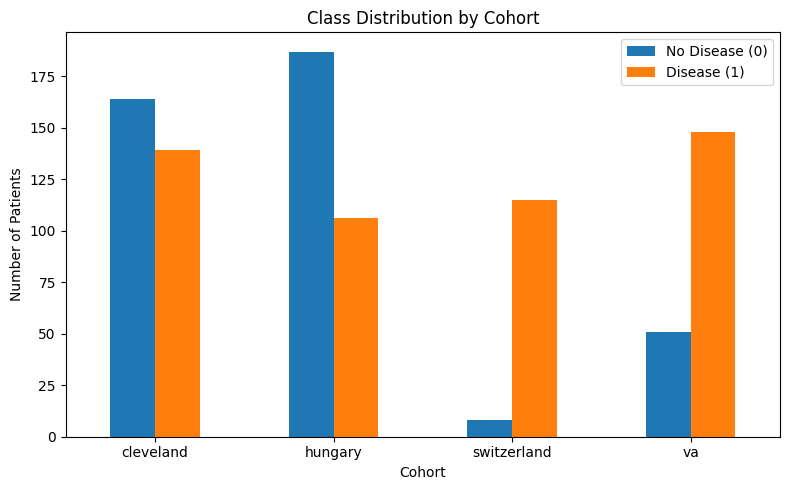

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

class_counts = []

for name, df in cleaned_data.items():
    counts = df["target_binary"].value_counts().sort_index()
    class_counts.append({
        "cohort": name,
        "no_disease_0": counts.get(0.0, 0),
        "disease_1": counts.get(1.0, 0)
    })

class_df = pd.DataFrame(class_counts)
class_df = class_df.set_index("cohort")

class_df.plot(kind="bar", figsize=(8, 5))
plt.title("Class Distribution by Cohort")
plt.xlabel("Cohort")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.legend(["No Disease (0)", "Disease (1)"])
plt.tight_layout()
plt.show()

**What we learn from this graph:**

- Cleveland and Hungary have slightly more no disease (0) cases, so they are relatively balanced
- Switzerland has mostly disease (1) cases, making it highly imbalanced
- VA Long Beach also has more disease cases than no disease
- Overall, class imbalance is present, especially in Switzerland and VA
- This may cause models to favor predicting disease if not handled properly

### 7.3: Missing Values Across Cohorts

This graph shows missing values across cohorts to compare data completeness.

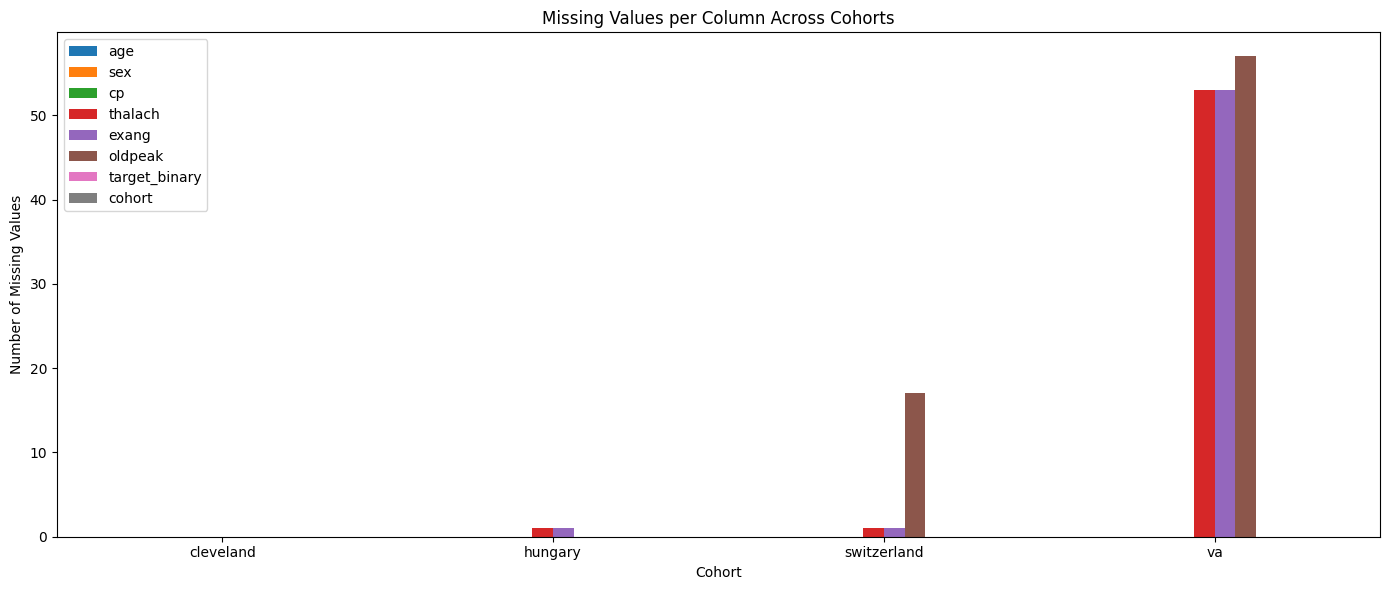

In [ ]:
missing_summary = {}

for name, df in cleaned_data.items():
    missing_summary[name] = df.isna().sum()

missing_df = pd.DataFrame(missing_summary).T

missing_df.plot(kind="bar", figsize=(14, 6))
plt.title("Missing Values per Column Across Cohorts")
plt.xlabel("Cohort")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**What we learn from this graph:**

- Cleveland has almost no missing values
- Hungary has extremely high missing values in slope
- VA has many missing values across several features
- Switzerland has some missing values but less than Hungary and VA
- Overall, missing data varies across cohorts and must be handled carefully

### 7.4: Feature Distributions and Dataset Merging

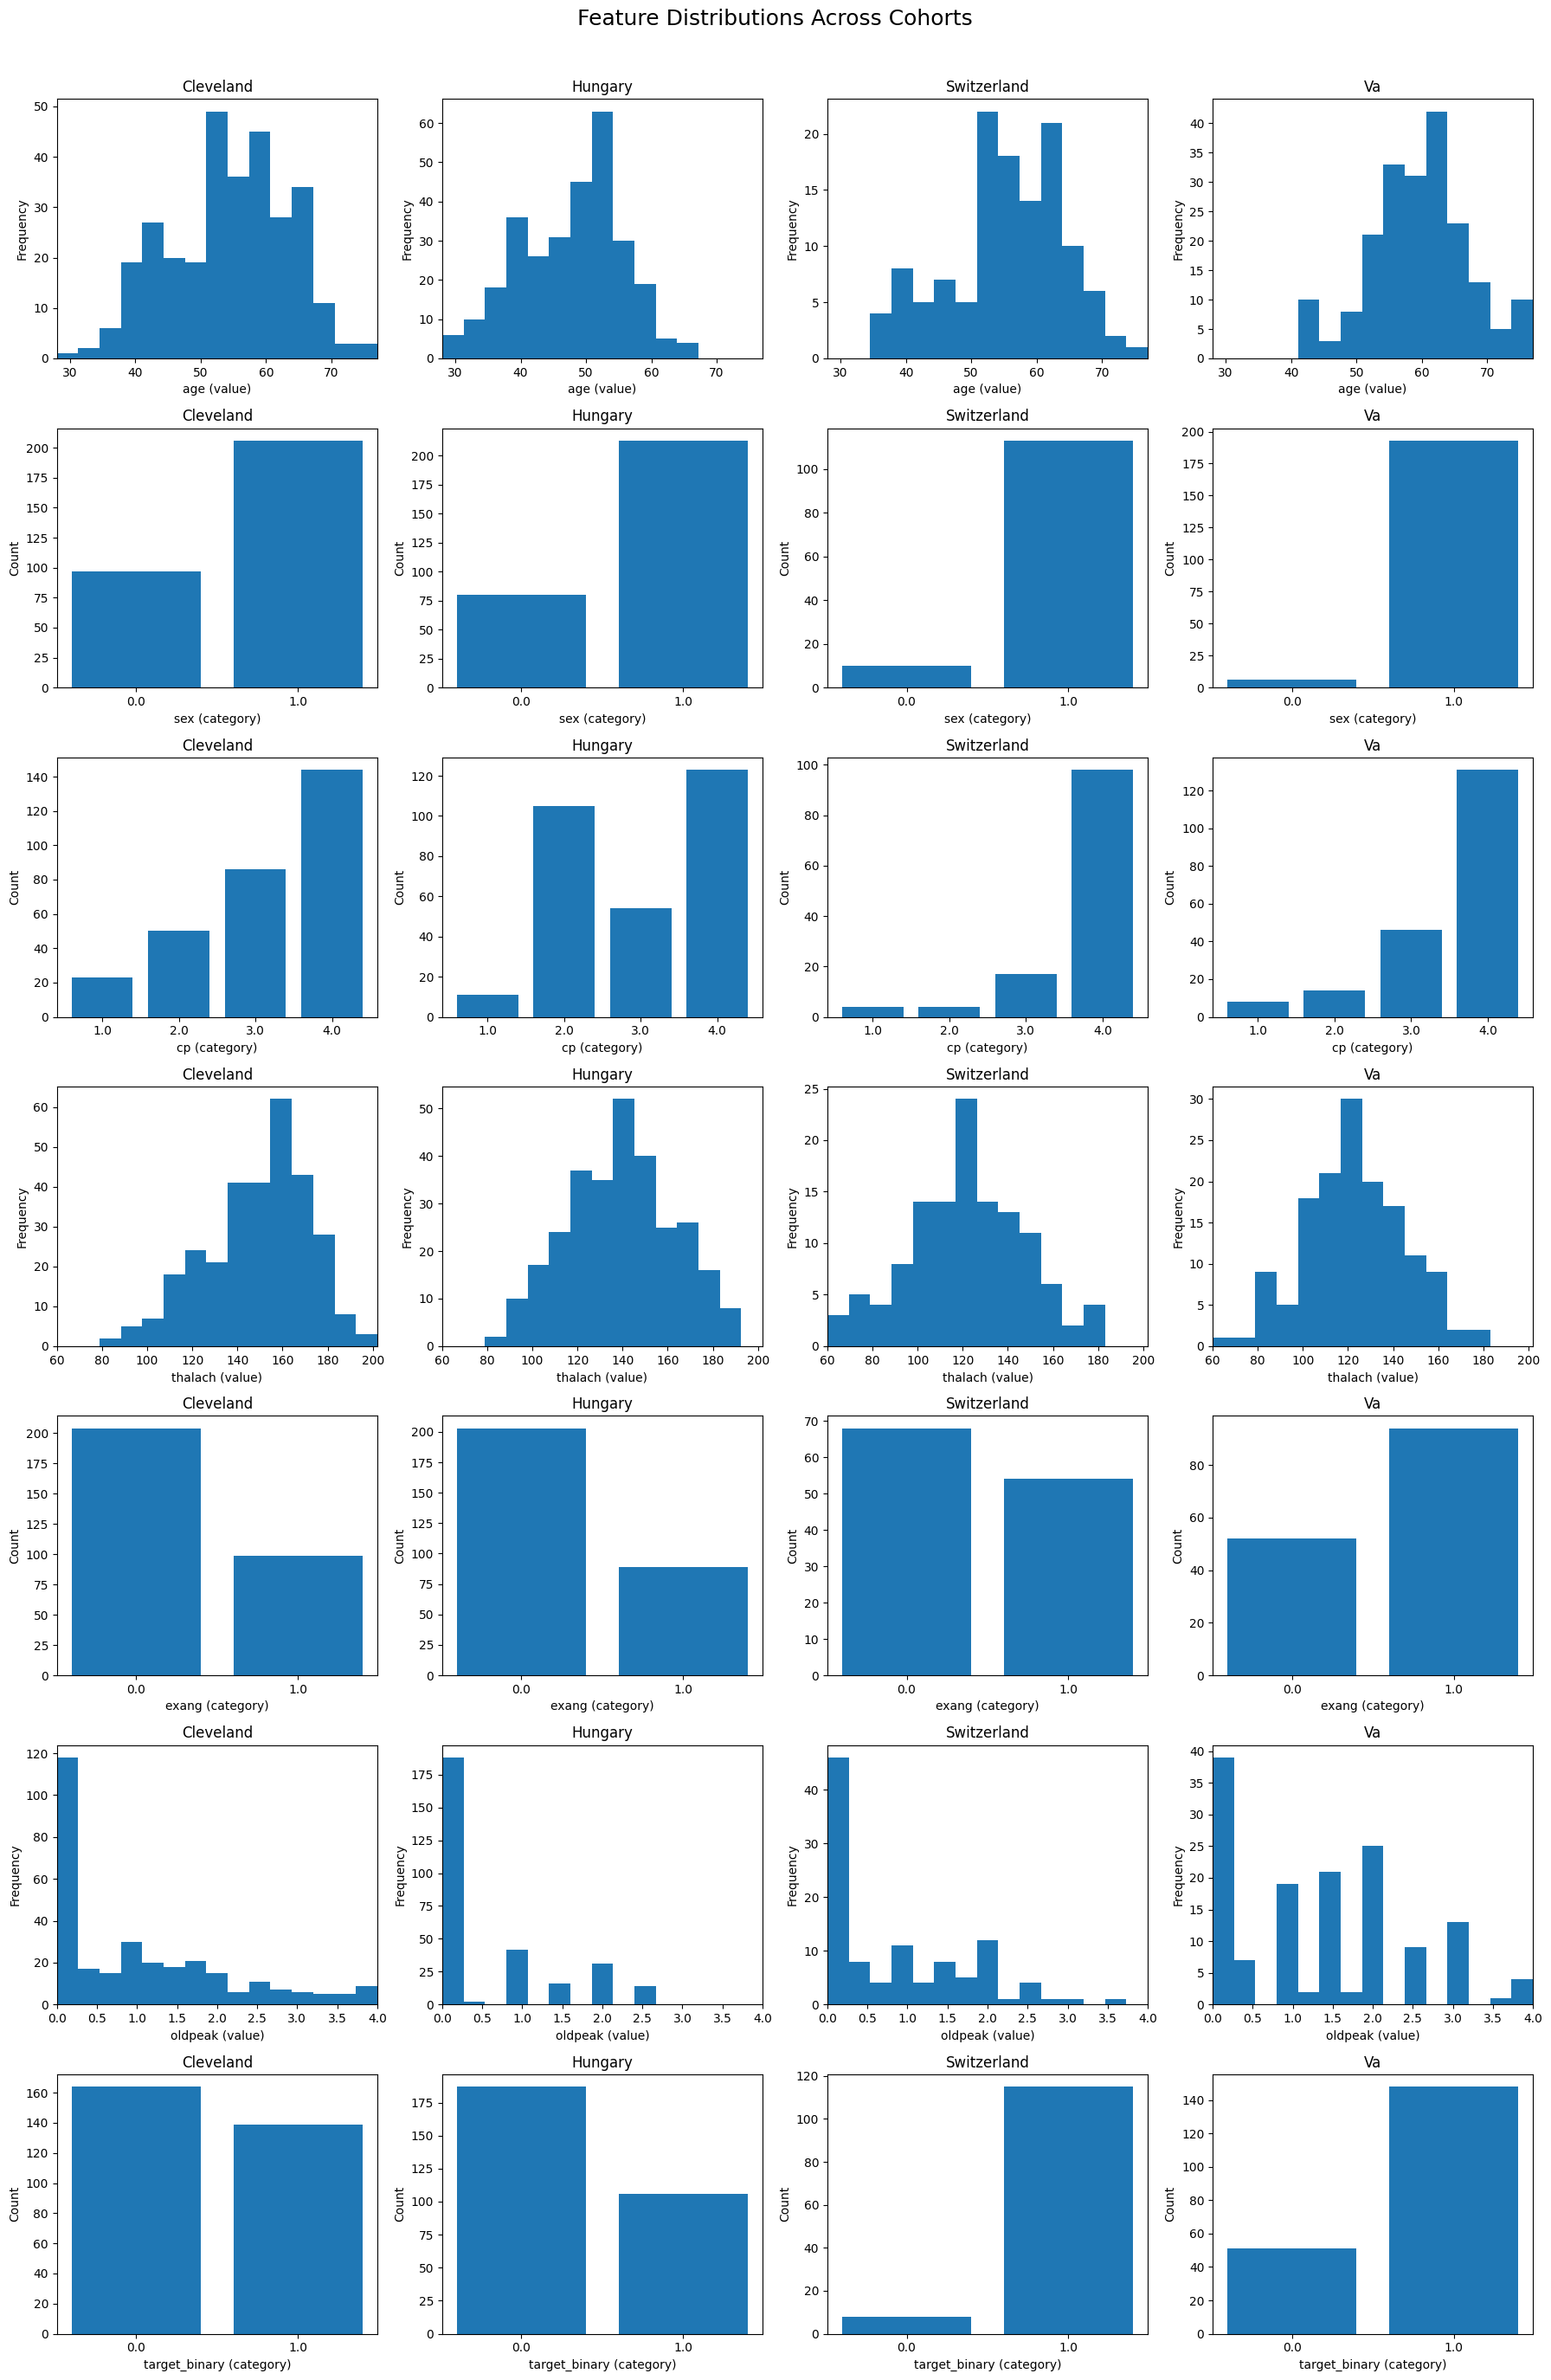

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

features_to_compare = [
    "age", "sex", "cp",
    "thalach", "exang", "oldpeak", "target_binary"
]

categorical_features = ["sex", "cp", "restecg", "exang", "slope", "target_binary"]
cohort_names = list(cleaned_data.keys())

fig, axes = plt.subplots(len(features_to_compare), 4, figsize=(18, 4 * len(features_to_compare)))

for row_idx, feature in enumerate(features_to_compare):

    # Get shared range for numeric features
    if feature not in categorical_features:
        all_values = pd.concat([
            cleaned_data[c][feature].dropna()
            for c in cohort_names if feature in cleaned_data[c].columns
        ])
        global_min = all_values.min()
        global_max = all_values.max()

    for col_idx, cohort in enumerate(cohort_names):
        ax = axes[row_idx, col_idx]
        df = cleaned_data[cohort]

        if feature not in df.columns:
            ax.set_visible(False)
            continue

        series = df[feature].dropna()

        # Categorical → bar chart
        if feature in categorical_features:
            value_counts = series.value_counts().sort_index()
            ax.bar(value_counts.index.astype(str), value_counts.values)

            ax.set_xlabel(f"{feature} (category)")
            ax.set_ylabel("Count")

        # Numerical → histogram
        else:
            ax.hist(series, bins=15, range=(global_min, global_max))
            ax.set_xlim(global_min, global_max)

            ax.set_xlabel(f"{feature} (value)")
            ax.set_ylabel("Frequency")

        # Column titles
        ax.set_title(cohort.capitalize(), fontsize=12)

plt.suptitle("Feature Distributions Across Cohorts", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

**What we learn from this graph:**

- *Age:* Similar distribution across all cohorts, mostly centered around middle age.
- *Sex:* All cohorts have more males than females, with Switzerland showing the strongest imbalance.
- *Chest Pain (cp):* Category 4 is generally the most common across cohorts, although Hungary shows a more balanced distribution.
- *Max Heart Rate (thalach):* Max heart rate shows a similar distribution across cohorts, with VA appearing slightly more concentrated around the center.
- *Exercise-Induced Angina (exang):* Exercise-induced angina is mostly absent (0) in Cleveland and Hungary, while VA shows a higher proportion of positive cases.
- *Oldpeak:* Oldpeak is skewed toward lower values across all cohorts, with greater variability in VA and Switzerland.
- *Target (target_binary):* Cleveland and Hungary are relatively balanced, while Switzerland and VA show a higher proportion of positive (disease) cases, with Switzerland being highly imbalanced.

####- Merging Cleveland and Hungary for External Training

After analyzing feature distributions across cohorts, the Cleveland and Hungary datasets are merged to create a larger and more stable training set for the external validation experiment.

In [ ]:
selected_features = ["age", "sex", "cp", "thalach", "exang", "oldpeak", "target_binary"]

cleveland_df = cleaned_data["cleveland"][selected_features]
hungary_df = cleaned_data["hungary"][selected_features]

merged_df = pd.concat([cleveland_df, hungary_df], ignore_index=True)

print("Merged dataset shape:", merged_df.shape)

Merged dataset shape: (596, 7)


The Cleveland and Hungary datasets were merged after selecting only the most relevant features based on the correlation analysis. Features with weak or inconsistent relationships with the target variable were removed to reduce noise and improve model performance.

This merging step increased the dataset size to 596 samples, allowing the models to learn more stable patterns. Using a larger and cleaner dataset helps improve generalization and reduces the risk of overfitting.

### 7.5: Correlation Heatmaps

This graph shows the correlation between features in each cohort, highlighting how strongly variables are related to each other.

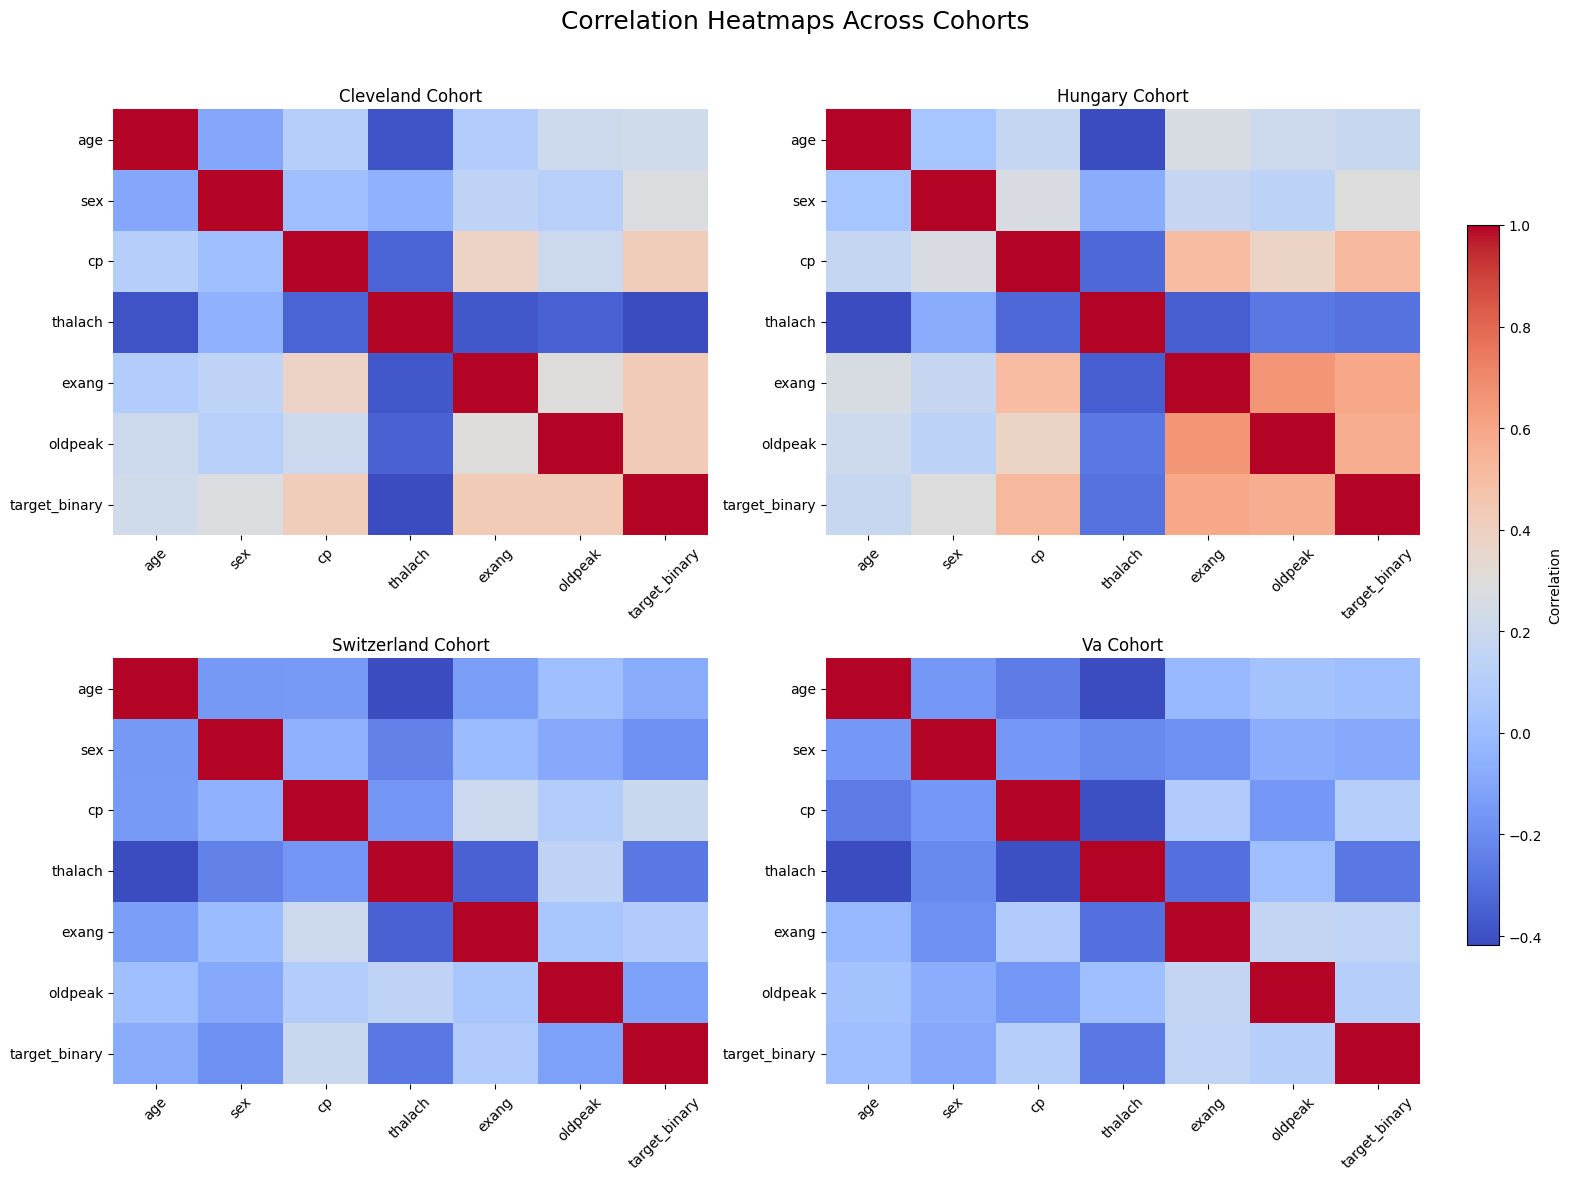

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

cohorts_list = ["cleveland", "hungary", "switzerland", "va"]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, cohort in enumerate(cohorts_list):
    df = cleaned_data[cohort].copy()

    # Select only numeric columns
    numeric_df = df.select_dtypes(include=[np.number])

    sns.heatmap(
        numeric_df.corr(),
        annot=False,
        cmap="coolwarm",
        ax=axes[i],
        cbar=False  # remove individual colorbars
    )

    axes[i].set_title(f"{cohort.capitalize()} Cohort")
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].tick_params(axis='y', rotation=0)

# Add ONE shared colorbar
cbar_ax = fig.add_axes([0.92, 0.2, 0.02, 0.6])  # [left, bottom, width, height]
cbar = fig.colorbar(axes[0].collections[0], cax=cbar_ax)
cbar.set_label("Correlation")

# Main title
plt.suptitle("Correlation Heatmaps Across Cohorts", fontsize=18)

plt.tight_layout(rect=[0, 0, 0.9, 0.96])
plt.show()

**What we learn from this graph:**
- *Age:* Shows weak and inconsistent correlation with the target across all cohorts (not a strong predictor).
- *Sex:* Has very little correlation with the target in all datasets → minimal impact on prediction.
- *Chest Pain (cp):* Moderately correlated with the target in Cleveland and Hungary, but weaker in Switzerland and VA → more useful in some cohorts than others.
- *Resting Blood Pressure (trestbps):* Generally weak correlation across all cohorts (limited predictive value).
- *Resting ECG (restecg):* Shows weak and inconsistent relationships with the target → not very informative.
- *Max Heart Rate (thalach):* Consistently shows a negative correlation with the target (higher values are associated with lower disease risk across most cohorts).
- **Exercise-Induced Angina (exang):** Moderately correlated with the target in most cohorts (a useful feature for prediction).
- *Oldpeak:* Strong positive correlation with the target in all cohorts → one of the most important features.
- *Slope:* Also shows a strong positive relationship with the target, especially in Cleveland and Hungary (another key predictor).
- *Target (target_binary):* Relationships differ slightly across cohorts, showing that feature importance is not identical.

### 7.6: Selected Variable Relationships

This graph shows how key variables relate to each other and to the target, helping identify important patterns and potential predictors of heart disease across cohorts.

In [ ]:
print(df.columns)

Index(['age', 'sex', 'cp', 'thalach', 'exang', 'oldpeak', 'target_binary',
       'cohort'],
      dtype='object')


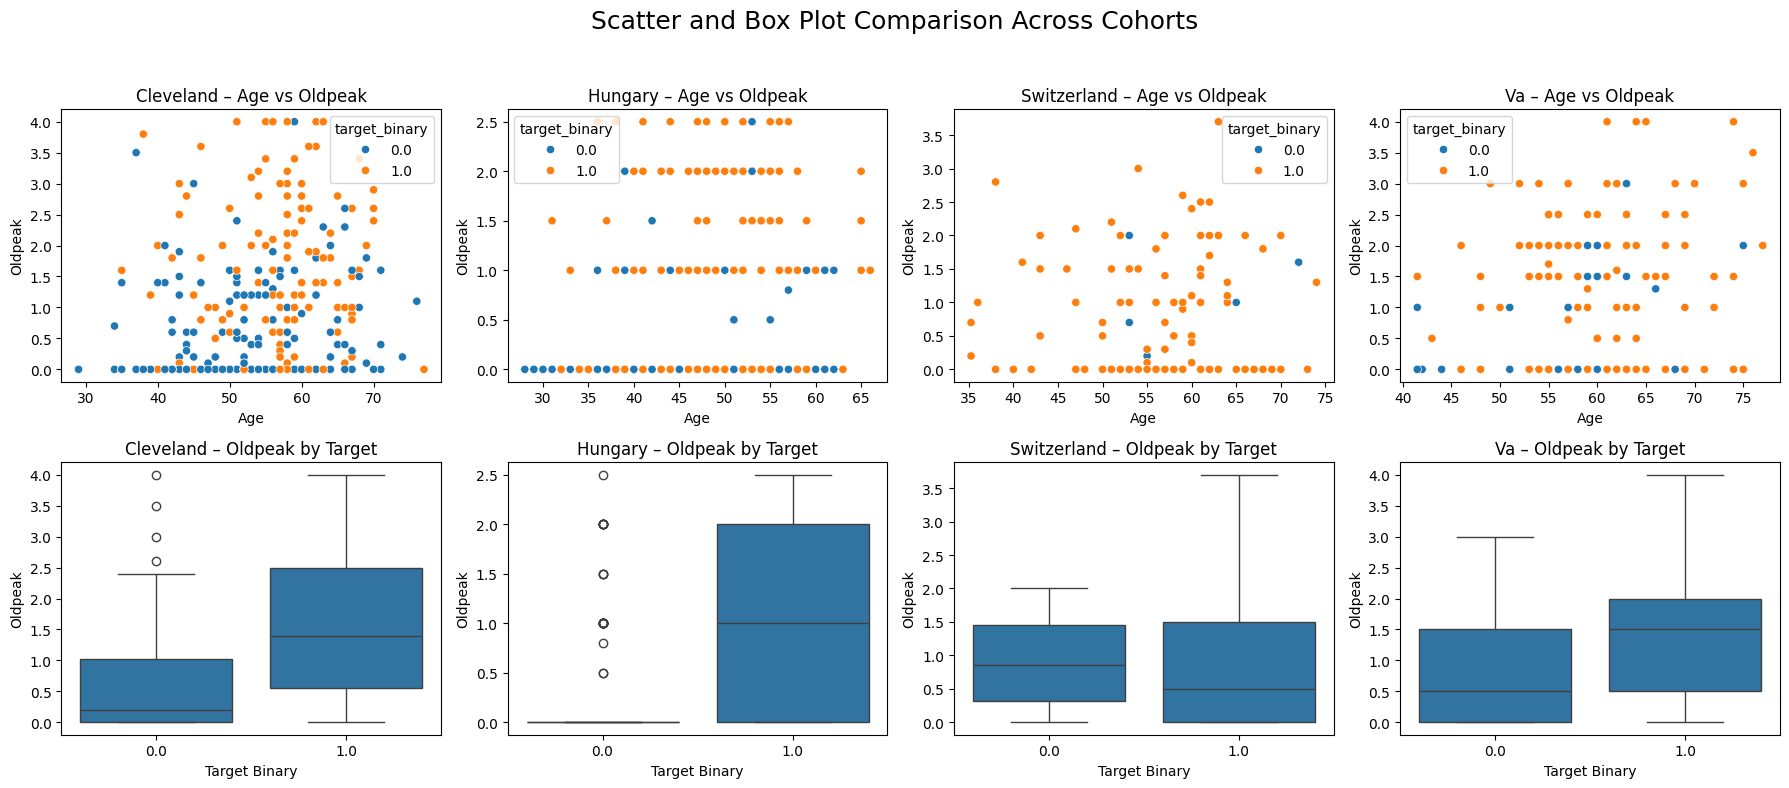

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cohorts_list = ["cleveland", "hungary", "switzerland", "va"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

# ---------- Row 1: Scatter plots ----------
for i, cohort in enumerate(cohorts_list):
    df = cleaned_data[cohort]

    sns.scatterplot(
        data=df,
        x="age",
        y="oldpeak",
        hue="target_binary",
        ax=axes[0, i]   # legend stays ON by default
    )

    axes[0, i].set_title(f"{cohort.capitalize()} – Age vs Oldpeak")
    axes[0, i].set_xlabel("Age")
    axes[0, i].set_ylabel("Oldpeak")

# ---------- Row 2: Box plots ----------
for i, cohort in enumerate(cohorts_list):
    df = cleaned_data[cohort]

    sns.boxplot(
        data=df,
        x="target_binary",
        y="oldpeak",
        ax=axes[1, i]
    )

    axes[1, i].set_title(f"{cohort.capitalize()} – Oldpeak by Target")
    axes[1, i].set_xlabel("Target Binary")
    axes[1, i].set_ylabel("Oldpeak")

plt.suptitle("Scatter and Box Plot Comparison Across Cohorts", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

**What we learn from this graph:**

***Scatter Plots/***
- *Cleveland (Age vs Oldpeak):* Points are more spread out, but higher oldpeak values are more frequent in disease cases. There is some overlap between classes.
- *Hungary (Age vs Oldpeak):* Values appear more clustered and discrete. The separation between disease and no disease is less clear compared to Cleveland.
- *Switzerland (Age vs Oldpeak):*
Strong concentration of disease cases across different oldpeak values. Most points belong to disease, showing class imbalance.
- *VA (Age vs Oldpeak):* Disease cases dominate, especially at higher oldpeak values. Slightly clearer pattern than Hungary but still overlapping.

***Box Plots/***
- *Cleveland (Blood Pressure by Target):* Disease cases have slightly higher median blood pressure, but distributions overlap a lot.
- *Hungary (Blood Pressure by Target):* Similar to Cleveland, with a small increase in blood pressure for disease cases, but still overlapping.
- *Switzerland (Blood Pressure by Target):* Very similar distributions for both classes (blood pressure is not very useful here).
- *VA (Blood Pressure by Target):* Slightly higher variation and some outliers, but still no clear separation between classes.

### 7.7: Outliers and IQR

This graph shows the distribution of continuous features across cohorts and helps identify potential outliers that may influence model performance.

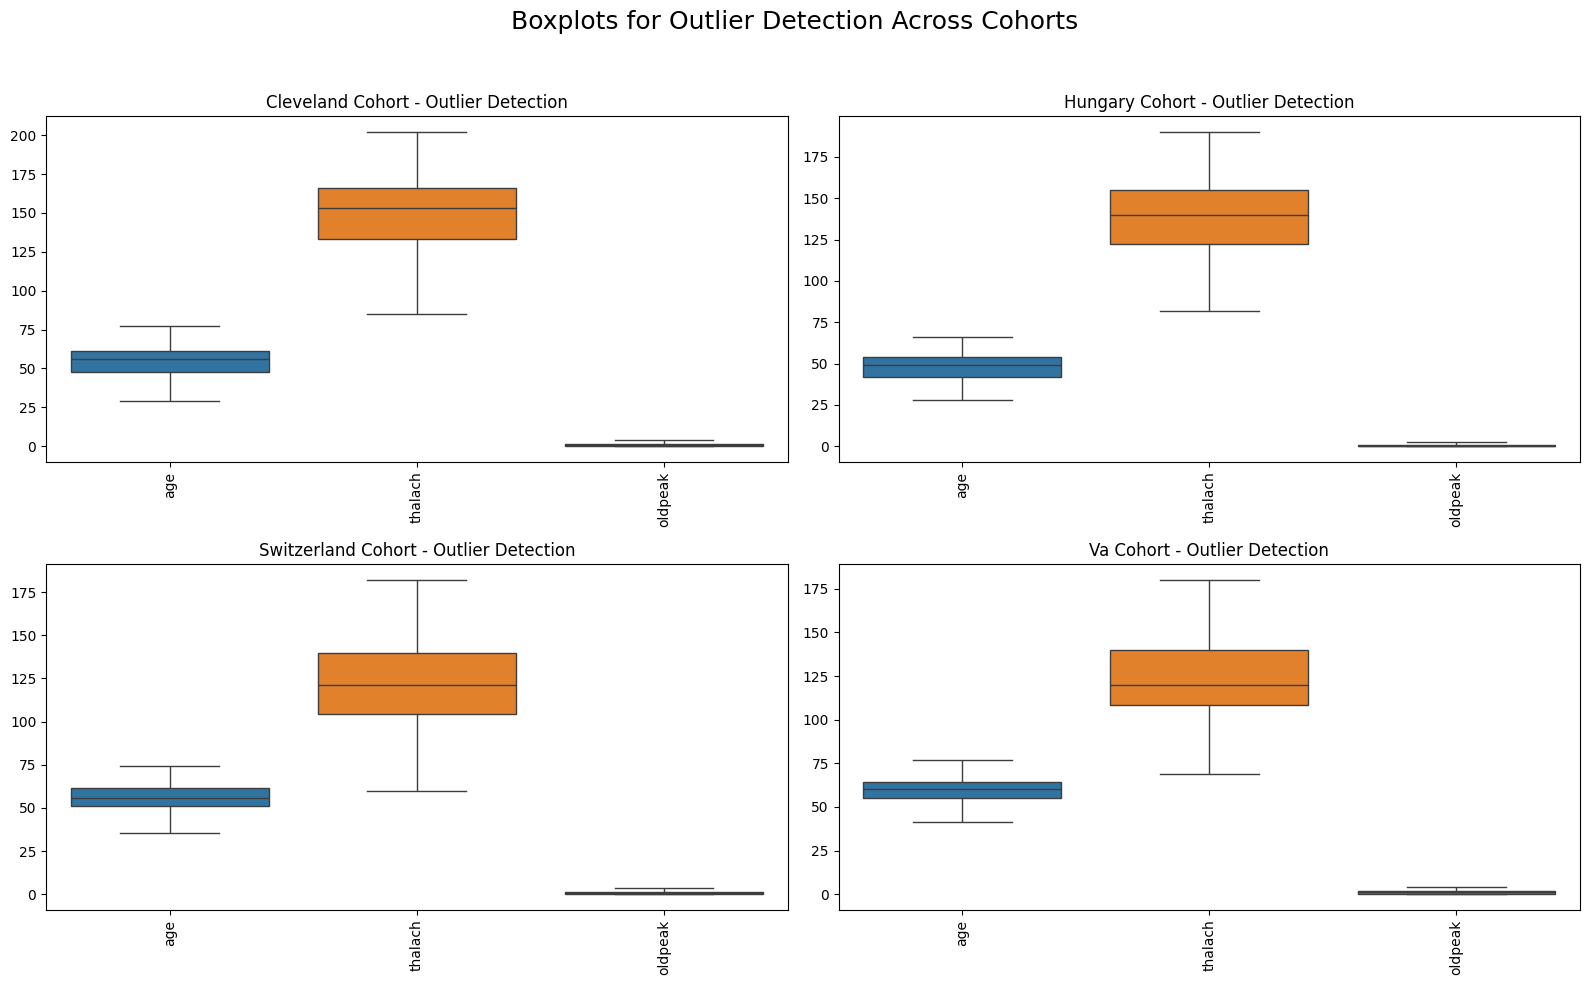

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cohorts_list = ["cleveland", "hungary", "switzerland", "va"]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, cohort in enumerate(cohorts_list):
    df = cleaned_data[cohort]

    outlier_features = ["age", "thalach", "oldpeak"]
    numeric_df = df[outlier_features].copy()

    sns.boxplot(data=numeric_df, ax=axes[i])

    axes[i].set_title(f"{cohort.capitalize()} Cohort - Outlier Detection")
    axes[i].set_xticklabels(outlier_features, rotation=90)

plt.suptitle("Boxplots for Outlier Detection Across Cohorts", fontsize=18)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

What we learn from this graph:

- The outlier analysis focuses on the continuous features: age, thalach, and oldpeak.
- Age is relatively consistent across cohorts, showing limited extreme values.
- Thalach demonstrates the greatest variability, indicating differences in maximum heart rate across patients and cohorts.
- Oldpeak has a narrower distribution but includes occasional higher values, reflecting variation in ST depression levels.
- Differences between cohorts are visible, particularly in thalach, suggesting potential distribution shifts across datasets.
- Overall, the features show manageable levels of outliers, meaning extreme values are unlikely to significantly distort model performance.

#### - Cleveland Outlier Counts

In [ ]:
from IPython.display import display

outlier_features = ["age", "thalach", "oldpeak"]
numeric_df = cleveland_cleaned[outlier_features].copy()

Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

outliers = ((numeric_df < (Q1 - 1.5 * IQR)) | (numeric_df > (Q3 + 1.5 * IQR)))

print("\n================ CLEVELAND OUTLIERS ================")

outlier_df = outliers.sum().reset_index()
outlier_df.columns = ["Column", "Number of Outliers"]

display(outlier_df)


================ CLEVELAND OUTLIERS ================


,Column,Number of Outliers
0,age,0
1,thalach,0
2,oldpeak,0


- All selected continuous features (age, thalach, and oldpeak) show no significant outliers in the Cleveland cohort.
- This indicates that the data is clean and does not contain extreme values that could distort model training.
- The absence of outliers suggests stable feature distributions for this cohort.
- Overall, the Cleveland dataset appears well-prepared for modeling with minimal need for outlier handling.

#### - Hungary Outlier Counts

In [ ]:
from IPython.display import display

outlier_features = ["age", "thalach", "oldpeak"]
numeric_df = hungary_cleaned[outlier_features].copy()

Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

outliers = ((numeric_df < (Q1 - 1.5 * IQR)) | (numeric_df > (Q3 + 1.5 * IQR)))

print("\n================ HUNGARY OUTLIERS ================")

outlier_df = outliers.sum().reset_index()
outlier_df.columns = ["Column", "Number of Outliers"]

display(outlier_df)


================ HUNGARY OUTLIERS ================


,Column,Number of Outliers
0,age,0
1,thalach,0
2,oldpeak,0


- All selected continuous features (age, thalach, and oldpeak) show no significant outliers in the Hungary cohort.
- This indicates that the data is clean and does not contain extreme values that could negatively affect model training.
- The distributions of these features appear stable and consistent.
- Overall, the Hungary dataset demonstrates good data quality with minimal outlier-related concerns.

#### - Switzerland Outlier Counts

In [ ]:
from IPython.display import display

outlier_features = ["age", "thalach", "oldpeak"]
numeric_df = switzerland_cleaned[outlier_features].copy()

Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

outliers = ((numeric_df < (Q1 - 1.5 * IQR)) | (numeric_df > (Q3 + 1.5 * IQR)))

print("\n================ SWITZERLAND OUTLIERS ================")

outlier_df = outliers.sum().reset_index()
outlier_df.columns = ["Column", "Number of Outliers"]

display(outlier_df)


================ SWITZERLAND OUTLIERS ================


,Column,Number of Outliers
0,age,0
1,thalach,0
2,oldpeak,0


- The continuous features (age, thalach, and oldpeak) do not exhibit significant outliers in the Switzerland cohort.
- This suggests stable distributions without extreme deviations in the selected variables.
- Although this cohort has known class imbalance, the feature values themselves remain consistent.
- Overall, the data appears suitable for modeling with minimal concern for outlier-driven distortion.

#### - VA Long Beach Outlier Counts

In [ ]:
from IPython.display import display

outlier_features = ["age", "thalach", "oldpeak"]
numeric_df = va_cleaned[outlier_features].copy()

Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

outliers = ((numeric_df < (Q1 - 1.5 * IQR)) | (numeric_df > (Q3 + 1.5 * IQR)))

print("\n================ VA LONG BEACH OUTLIERS ================")

outlier_df = outliers.sum().reset_index()
outlier_df.columns = ["Column", "Number of Outliers"]

display(outlier_df)


================ VA LONG BEACH OUTLIERS ================


,Column,Number of Outliers
0,age,0
1,thalach,0
2,oldpeak,0


- The continuous features (age, thalach, and oldpeak) do not exhibit notable outliers in the VA Long Beach cohort.
- This reflects stable and well-behaved feature distributions.
- The absence of extreme values supports reliable model training and reduces the risk of bias.
- Overall, the dataset appears clean and suitable for machine learning tasks.

### 7.8: Scaling Preview

This step shows how the data looks after applying feature scaling.

- Numerical features are transformed using StandardScaler
- Each numerical feature is adjusted to have mean = 0 and standard deviation = 1
- This ensures that variables are on a comparable scale, preventing features with larger magnitudes from dominating
- In this preview, numeric columns are scaled for illustration purposes. In the actual modeling pipeline, only continuous features (`age`, `thalach`, `oldpeak`) are scaled, while categorical features (`sex`, `cp`, `exang`) are one-hot encoded.
- The cohort column remains unchanged as it is non-numeric
- This is only a preview of the scaled data

Scaling helps machine learning models perform better, especially those sensitive to feature magnitude.

This preview is for illustration only. In the actual modeling pipeline, numerical features are scaled while categorical features are imputed and one-hot encoded separately.

#### - Cleveland Scaling Preview

In [ ]:
from sklearn.preprocessing import StandardScaler
from IPython.display import display

X_example = cleveland_cleaned.drop(columns=["target_binary"])
numeric_cols = X_example.select_dtypes(include=[np.number]).columns

scaler = StandardScaler()

X_scaled = X_example.copy()
X_scaled[numeric_cols] = scaler.fit_transform(X_example[numeric_cols])

print("Scaled preview from Cleveland:")

# Preview of scaled dataset
preview_df = X_scaled.head()

display(preview_df)

Scaled preview from Cleveland:


,age,sex,cp,thalach,exang,oldpeak,cohort
0,0.948726,0.686202,-2.251775,0.015306,-0.696631,1.150938,cleveland
1,1.392002,0.686202,0.877985,-1.835388,1.435481,0.429108,cleveland
2,1.392002,0.686202,0.877985,-0.910041,1.435481,1.421625,cleveland
3,-1.932564,0.686202,-0.165268,1.645679,-0.696631,2.233684,cleveland
4,-1.489288,-1.457296,-1.208521,0.984717,-0.696631,0.338879,cleveland


#### - Hungary Scaling Preview

In [ ]:
from sklearn.preprocessing import StandardScaler
from IPython.display import display

X_example = hungary_cleaned.drop(columns=["target_binary"])
numeric_cols = X_example.select_dtypes(include=[np.number]).columns

scaler = StandardScaler()

X_scaled = X_example.copy()
X_scaled[numeric_cols] = scaler.fit_transform(X_example[numeric_cols])

print("Scaled preview from Hungary:")

preview_df = X_scaled.head()
display(preview_df)

Scaled preview from Hungary:


,age,sex,cp,thalach,exang,oldpeak,cohort
0,-2.537605,0.612851,-1.023819,1.950156,-0.662136,-0.679943,hungary
1,-2.409588,0.612851,-1.023819,0.888946,-0.662136,-0.679943,hungary
2,-2.409588,0.612851,-1.023819,1.313430,-0.662136,-0.679943,hungary
3,-2.281572,-1.631717,-2.061808,1.313430,-0.662136,-0.679943,hungary
4,-2.153556,-1.631717,-1.023819,0.464461,-0.662136,-0.679943,hungary


#### - Switzerland Scaling Preview

In [ ]:
from sklearn.preprocessing import StandardScaler
from IPython.display import display

X_example = switzerland_cleaned.drop(columns=["target_binary"])
numeric_cols = X_example.select_dtypes(include=[np.number]).columns

scaler = StandardScaler()

X_scaled = X_example.copy()
X_scaled[numeric_cols] = scaler.fit_transform(X_example[numeric_cols])

print("Scaled preview from Switzerland:")

preview_df = X_scaled.head()
display(preview_df)

Scaled preview from Switzerland:


,age,sex,cp,thalach,exang,oldpeak,cohort
0,-2.258279,0.297482,-3.935130,0.210377,-0.891133,-0.151213,switzerland
1,-2.258279,0.297482,0.438554,1.254027,-0.891133,-0.703922,switzerland
2,-2.258279,0.297482,0.438554,0.326339,1.122167,NaN,switzerland
3,-2.174039,0.297482,0.438554,0.133070,1.122167,0.180413,switzerland
4,-1.949398,-3.361547,0.438554,1.717871,-0.891133,2.170167,switzerland


#### - VA Long Beach Scaling Preview

In [ ]:
from sklearn.preprocessing import StandardScaler
from IPython.display import display

X_example = va_cleaned.drop(columns=["target_binary"])
numeric_cols = X_example.select_dtypes(include=[np.number]).columns

scaler = StandardScaler()

X_scaled = X_example.copy()
X_scaled[numeric_cols] = scaler.fit_transform(X_example[numeric_cols])

print("Scaled preview from VA Long Beach:")

preview_df = X_scaled.head()
display(preview_df)

Scaled preview from VA Long Beach:


,age,sex,cp,thalach,exang,oldpeak,cohort
0,0.469076,0.176318,0.619534,-0.492514,0.743768,1.515033,va
1,-2.041292,0.176318,0.619534,0.189716,-1.344504,-1.227865,va
2,0.072702,0.176318,0.619534,0.780982,0.743768,0.143584,va
3,-0.587921,0.176318,0.619534,1.190320,0.743768,1.057883,va
4,0.865449,0.176318,-0.638499,-1.083780,0.743768,-0.039276,va


### 7.9: Summary Table

This table summarizes key statistics of each feature, helping understand data distribution, ranges, and overall data quality across cohorts.

In [ ]:
summary_rows = []

for name, df in cleaned_data.items():
    summary_rows.append({
        "cohort": name,
        "rows": df.shape[0],
        "columns": df.shape[1],
        "missing_values": df.isna().sum().sum(),   # ← comma here
        "missing_percent": round(df.isna().sum().sum() / (df.shape[0]*df.shape[1]) * 100, 2),
        "disease_cases": df["target_binary"].sum(),
        "non_disease_cases": (df["target_binary"] == 0).sum()
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

,cohort,rows,columns,missing_values,missing_percent,disease_cases,non_disease_cases
0,cleveland,303,8,0,0.00,139.0,164
1,hungary,293,8,2,0.09,106.0,187
2,switzerland,123,8,19,1.93,115.0,8
3,va,199,8,163,10.24,148.0,51


## Step 8: Save Cleaned Datasets

This step saves the cleaned datasets as CSV files, allowing the processed data to be reused for later analysis and modeling.

In [ ]:
output_dir = Path("project_outputs")
output_dir.mkdir(exist_ok=True)

for name, df in cleaned_data.items():
    df.to_csv(output_dir / f"{name}_cleaned.csv", index=False)

print("Cleaned datasets saved.")
for name in cleaned_data:
    print(output_dir / f"{name}_cleaned.csv")

Cleaned datasets saved.
project_outputs/cleveland_cleaned.csv
project_outputs/hungary_cleaned.csv
project_outputs/switzerland_cleaned.csv
project_outputs/va_cleaned.csv


## Step 9: Machine Learning Preprocessing and Modeling Pipeline

This step builds a machine learning pipeline that combines data preprocessing and modeling into one process.

The pipeline handles:

- Missing values (median for numeric, most frequent for categorical)
- Feature scaling for numeric variables
- One-hot encoding for categorical variables

Preprocessing is applied within the pipeline to avoid data leakage and ensure consistent transformations during training and testing.

### 9.1 Define Preprocessing Steps

This section defines how different types of data are handled.

Numeric features are scaled and imputed, while categorical features are encoded.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_cols = ["age", "thalach", "oldpeak"]
categorical_cols = ["sex", "cp", "exang"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

### 9.2: Build the Pipeline

This function creates a full machine learning pipeline that combines preprocessing and the model into one process.

It ensures that all transformations are applied consistently during both training and testing.

In [ ]:
def build_pipeline(model):
    numeric_cols = ["age", "thalach", "oldpeak"]
    categorical_cols = ["sex", "cp", "exang"]

    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_cols),
            ("cat", categorical_transformer, categorical_cols)
        ]
    )

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    return pipeline

### 9.3: Verify Missing Values After Preprocessing

This step applies the preprocessing pipeline to each dataset and checks for remaining missing values.
The result shows that all missing values have been handled successfully (0 remaining), confirming the data is ready for modeling.

In [ ]:
# VERIFY IMPUTATION FOR ALL DATASETS

import numpy as np

for name, df in cleaned_data.items():
    print(f"\n===== {name.upper()} =====")

    X = df.drop(columns=["target_binary", "cohort"])

    # Apply preprocessing
    X_transformed = preprocessor.fit_transform(X)

    # Count missing values after pipeline
    missing_after = np.isnan(X_transformed).sum()

    print("Missing values after preprocessing:", missing_after)


===== CLEVELAND =====
Missing values after preprocessing: 0

===== HUNGARY =====
Missing values after preprocessing: 0

===== SWITZERLAND =====
Missing values after preprocessing: 0

===== VA =====
Missing values after preprocessing: 0


## Model Selection and Justification

We selected Logistic Regression and Random Forest for this task.

- The dataset is binary (heart disease: 0/1), so Logistic Regression is suitable as a simple baseline model
- The data is mixed (numeric and categorical) and noisy, so Random Forest can handle it effectively.
The data may contain non-linear patterns, which Random Forest can capture better than Logistic Regression

**Model roles:**

- Logistic Regression: simple and interpretable baseline
- Random Forest: captures complex patterns and feature interactions

We use both models to compare a simple model versus a more powerful model.

## Step 10: External Cross-Cohort Validation

This is the main experiment of the project.
For external validation, the **Cleveland** and **Hungary** cohorts are combined to form the training dataset, while the **Switzerland** and **VA** cohorts are used as external test datasets.

This approach evaluates how well the model generalizes to completely unseen populations. It is more realistic than internal validation because the model is tested on entirely different datasets rather than a split from the same cohort.

**Metrics used:**

- **Accuracy:** % of total predictions that are correct  
- **Precision:** Out of predicted “disease”, how many are actually disease  
- **Recall:** Out of actual “disease”, how many were correctly detected  
- **F1-score:** Balance between precision and recall  
- **ROC-AUC:** How well the model separates the two classes (higher = better)

### 10.1: Evaluation Function

This function trains the model on the merged Cleveland and Hungary datasets and evaluates it on a selected external cohort. It computes performance metrics including accuracy, precision, recall, F1-score, and ROC-AUC.

In [ ]:
def evaluate_model_merged(test_name, model_name, model, cleaned_data):
    target_col = "target_binary"

    # IMPORTANT: ensure target is NOT inside selected_features
    features = ["age", "sex", "cp", "thalach", "exang", "oldpeak"]
    cols_to_use = features + [target_col]

    # Merge Cleveland + Hungary for training
    train_df = pd.concat(
        [
            cleaned_data["cleveland"][cols_to_use],
            cleaned_data["hungary"][cols_to_use]
        ],
        ignore_index=True
    ).copy()

    # External test set
    test_df = cleaned_data[test_name][cols_to_use].copy()

    # Drop missing target values
    train_df = train_df.dropna(subset=[target_col]).reset_index(drop=True)
    test_df = test_df.dropna(subset=[target_col]).reset_index(drop=True)

    # Split features and target
    X_train = train_df.drop(columns=[target_col])
    y_train = train_df[target_col].astype(int).values.ravel()

    X_test = test_df.drop(columns=[target_col])
    y_test = test_df[target_col].astype(int).values.ravel()

    # Build pipeline
    pipeline = build_pipeline(model)
    pipeline.fit(X_train, y_train)

    # Predictions
    y_pred = pipeline.predict(X_test)

    # Probabilities (if available)
    if hasattr(pipeline.named_steps["model"], "predict_proba"):
        y_proba = pipeline.predict_proba(X_test)[:, 1]
    else:
        y_proba = None

    # Store results
    results = {
        "model": model_name,
        "train_cohort": "cleveland+hungary",
        "test_cohort": test_name,
        "n_train": len(train_df),
        "n_test": len(test_df),
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0)
    }

    if y_proba is not None and len(np.unique(y_test)) == 2:
        results["roc_auc"] = roc_auc_score(y_test, y_proba)
    else:
        results["roc_auc"] = np.nan

    return results, y_test, y_pred

### 10.2:  Model Definitions

We define the machine learning models used in this experiment, including Logistic Regression and Random Forest.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "RandomForest": RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42
    ),
}

### 10.3:  Logistic Regression External Validation

Logistic Regression is evaluated using the merged Cleveland and Hungary training set and tested on the Switzerland and VA cohorts to assess cross-cohort generalization.

In [ ]:
from IPython.display import display

logreg_results = []
logreg_reports = []

model_name = "LogisticRegression"
model = models[model_name]

print(f"\n================ MODEL: {model_name} ================")

test_cohorts = ["switzerland", "va"]

for test_name in test_cohorts:

    result, y_test, y_pred = evaluate_model_merged(
        test_name=test_name,
        model_name=model_name,
        model=model,
        cleaned_data=cleaned_data
    )

    logreg_results.append(result)

    logreg_reports.append({
        "model": model_name,
        "train_cohort": "cleveland+hungary",
        "test_cohort": test_name,
        "confusion_matrix": confusion_matrix(y_test, y_pred),
        "classification_report": classification_report(y_test, y_pred, zero_division=0)
    })

logreg_df = pd.DataFrame(logreg_results)

print("\nLogistic Regression Results")
display(logreg_df)


================ MODEL: LogisticRegression ================

Logistic Regression Results


,model,train_cohort,test_cohort,n_train,n_test,accuracy,precision,recall,f1,roc_auc
0,LogisticRegression,cleveland+hungary,switzerland,596,123,0.739837,0.966292,0.747826,0.843137,0.758696
1,LogisticRegression,cleveland+hungary,va,596,199,0.753769,0.861314,0.797297,0.828070,0.757750


**What we learn from Logistic Regression results:**

- The model demonstrates moderate but stable generalization when trained on the merged Cleveland and Hungary datasets and tested on external cohorts.
- Performance is consistent across Switzerland and VA, with accuracy around 74–75%.
- Precision is high, especially for Switzerland (≈0.97), indicating strong ability to correctly identify positive cases.
- Recall is slightly lower than precision, meaning some positive cases are missed.
- The F1-score remains stable across both cohorts (≈0.82–0.84), reflecting a balanced trade-off between precision and recall.
- ROC-AUC scores (~0.75–0.76) indicate moderate but reliable class separation.

Overall, Logistic Regression provides stable, balanced, and consistent performance across cohorts, making it a strong baseline model for this task.

### 10.4: Random Forest External Validation

Random Forest is trained on the merged Cleveland and Hungary dataset and evaluated on the Switzerland and VA cohorts to compare its external generalization with Logistic Regression.

In [ ]:
from IPython.display import display

rf_results = []
rf_reports = []

model_name = "RandomForest"
model = models[model_name]

print(f"\n================ MODEL: {model_name} ================")

test_cohorts = ["switzerland", "va"]

for test_name in test_cohorts:

    result, y_test, y_pred = evaluate_model_merged(
        test_name=test_name,
        model_name=model_name,
        model=model,
        cleaned_data=cleaned_data
    )

    rf_results.append(result)

    rf_reports.append({
        "model": model_name,
        "train_cohort": "cleveland+hungary",
        "test_cohort": test_name,
        "confusion_matrix": confusion_matrix(y_test, y_pred),
        "classification_report": classification_report(y_test, y_pred, zero_division=0)
    })

rf_df = pd.DataFrame(rf_results)

print("\nRandom Forest Results")
display(rf_df)


================ MODEL: RandomForest ================

Random Forest Results


,model,train_cohort,test_cohort,n_train,n_test,accuracy,precision,recall,f1,roc_auc
0,RandomForest,cleveland+hungary,switzerland,596,123,0.642276,0.973333,0.634783,0.768421,0.765217
1,RandomForest,cleveland+hungary,va,596,199,0.648241,0.861111,0.628378,0.726562,0.725755


**What we learn from Random Forest results:**

- The model demonstrates limited generalization across cohorts when trained on the merged dataset and evaluated on external cohorts.
- Accuracy is lower than Logistic Regression, around 64–65% across Switzerland and VA.
- Precision remains high (≈0.86–0.97), indicating that predicted positive cases are often correct.
- Recall is noticeably lower (≈0.63), suggesting that the model misses a significant number of positive cases.
- The F1-score (~0.72–0.77) is lower than Logistic Regression, indicating less balanced performance.
- ROC-AUC values (~0.72–0.76) show moderate class separation, but not an improvement over Logistic Regression.

Overall, Random Forest performs reasonably well but does not outperform Logistic Regression. The results suggest that increased model complexity does not necessarily improve generalization in this scenario.

### - Final Comparison and Conclusion

Both models demonstrate moderate generalization across cohorts, indicating that training on combined datasets can improve robustness.

Logistic Regression clearly outperforms Random Forest in this experiment, achieving higher accuracy and F1-scores across both Switzerland and VA. This suggests that simpler models may generalize better for structured medical data.

Random Forest, despite being more complex, does not improve performance and shows lower accuracy and less balanced results. This highlights that increased model complexity does not always lead to better outcomes.

Although Random Forest performed well during internal validation, Logistic Regression showed better external generalization. This suggests that simpler models may capture more stable cross-cohort patterns than more complex models.

It is also important to consider dataset characteristics. The Switzerland cohort is highly imbalanced, which may affect performance metrics and lead to misleading results if not interpreted carefully. Therefore, cross-cohort evaluation is essential for obtaining a realistic assessment of model performance.

Overall, Logistic Regression provides a strong and reliable baseline for this task. With proper feature selection and consistent preprocessing, simpler models can outperform more complex approaches in cross-cohort generalization.

## Step 11: Internal Validation

In this step, we evaluate model performance within each cohort using a train-test split from the same dataset.

This allows us to compare internal performance with external validation and assess whether models are overfitting to individual cohort distributions.

### 11.1: Logistic Regression Internal Validation

This code evaluates Logistic Regression performance within each cohort using a train-test split.
It calculates accuracy, precision, recall, F1-score, and ROC-AUC.

In [ ]:
from IPython.display import display

logreg_internal_results = []

model_name = "LogisticRegression"
model = models[model_name]
target_col = "target_binary"

print(f"\n================ INTERNAL VALIDATION: {model_name} ================")

internal_cohorts = ["cleveland", "hungary", "switzerland", "va"]
selected_features = ["age", "sex", "cp", "thalach", "exang", "oldpeak"]

for cohort_name in internal_cohorts:
    cols_to_use = selected_features + [target_col]
    df = cleaned_data[cohort_name][cols_to_use].copy()
    df = df.dropna(subset=[target_col]).reset_index(drop=True)

    X = df.drop(columns=[target_col])
    y = df[target_col].astype(int)

    if len(y.unique()) < 2 or len(df) < 10:
        continue

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.30,
        random_state=42,
        stratify=y
    )

    pipeline = build_pipeline(model)
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    if hasattr(pipeline.named_steps["model"], "predict_proba"):
        y_proba = pipeline.predict_proba(X_test)[:, 1]
    else:
        y_proba = None

    row = {
        "model": model_name,
        "cohort": cohort_name,
        "n_total": len(df),
        "internal_accuracy": accuracy_score(y_test, y_pred),
        "internal_precision": precision_score(y_test, y_pred, zero_division=0),
        "internal_recall": recall_score(y_test, y_pred, zero_division=0),
        "internal_f1": f1_score(y_test, y_pred, zero_division=0)
    }

    if y_proba is not None and len(np.unique(y_test)) == 2:
        row["internal_roc_auc"] = roc_auc_score(y_test, y_proba)
    else:
        row["internal_roc_auc"] = np.nan

    logreg_internal_results.append(row)

logreg_internal_df = pd.DataFrame(logreg_internal_results)

print("\nLogistic Regression Internal Validation Results")
display(logreg_internal_df)


================ INTERNAL VALIDATION: LogisticRegression ================

Logistic Regression Internal Validation Results


,model,cohort,n_total,internal_accuracy,internal_precision,internal_recall,internal_f1,internal_roc_auc
0,LogisticRegression,cleveland,303,0.824176,0.825000,0.785714,0.804878,0.890671
1,LogisticRegression,hungary,293,0.840909,0.800000,0.750000,0.774194,0.925781
2,LogisticRegression,switzerland,123,0.945946,0.945946,1.000000,0.972222,0.557143
3,LogisticRegression,va,199,0.800000,0.800000,0.977778,0.880000,0.765185


**What we learn from Logistic Regression results:**

- The model achieves strong internal performance across all cohorts, with accuracy ranging from approximately 80% to 95%, depending on the cohort.
- Internal validation results are consistently higher than external validation, indicating that models perform better when trained and tested on the same cohort distribution.
- Cleveland and Hungary show stable and balanced performance across all metrics.
- Switzerland achieves the highest accuracy and F1-score, but this is accompanied by perfect recall (1.0) but low ROC-AUC (~0.56), suggesting the model predicts most cases as positive due to class imbalance, suggesting the effect of class imbalance rather than true predictive strength.
- VA shows high recall (~0.98), indicating that most positive cases are correctly identified, but with slightly lower precision.

**Key insight:** High internal performance does not necessarily translate to strong generalization across different cohorts.

### 11.2: Random Forest Internal Validation

This code evaluates Random Forest performance within each cohort using a train-test split.

It applies the same metrics to allow direct comparison with Logistic Regression.

In [ ]:
from IPython.display import display

rf_internal_results = []

model_name = "RandomForest"
model = models[model_name]
target_col = "target_binary"

print(f"\n================ INTERNAL VALIDATION: {model_name} ================")

internal_cohorts = ["cleveland", "hungary", "switzerland", "va"]
selected_features = ["age", "sex", "cp", "thalach", "exang", "oldpeak"]

for cohort_name in internal_cohorts:
    cols_to_use = selected_features + [target_col]
    df = cleaned_data[cohort_name][cols_to_use].copy()
    df = df.dropna(subset=[target_col]).reset_index(drop=True)

    X = df.drop(columns=["target_binary"])
    y = df[target_col].astype(int)

    if len(y.unique()) < 2 or len(df) < 10:
        continue

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.30,
        random_state=42,
        stratify=y
    )

    pipeline = build_pipeline(model)
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    if hasattr(pipeline.named_steps["model"], "predict_proba"):
        y_proba = pipeline.predict_proba(X_test)[:, 1]
    else:
        y_proba = None

    row = {
        "model": model_name,
        "cohort": cohort_name,
        "n_total": len(df),
        "internal_accuracy": accuracy_score(y_test, y_pred),
        "internal_precision": precision_score(y_test, y_pred, zero_division=0),
        "internal_recall": recall_score(y_test, y_pred, zero_division=0),
        "internal_f1": f1_score(y_test, y_pred, zero_division=0)
    }

    if y_proba is not None and len(np.unique(y_test)) == 2:
        row["internal_roc_auc"] = roc_auc_score(y_test, y_proba)
    else:
        row["internal_roc_auc"] = np.nan

    rf_internal_results.append(row)

rf_internal_df = pd.DataFrame(rf_internal_results)

print("\nRandom Forest Internal Validation Results")
display(rf_internal_df)


================ INTERNAL VALIDATION: RandomForest ================

Random Forest Internal Validation Results


,model,cohort,n_total,internal_accuracy,internal_precision,internal_recall,internal_f1,internal_roc_auc
0,RandomForest,cleveland,303,0.780220,0.761905,0.761905,0.761905,0.878523
1,RandomForest,hungary,293,0.829545,0.742857,0.812500,0.776119,0.915179
2,RandomForest,switzerland,123,0.945946,0.945946,1.000000,0.972222,0.514286
3,RandomForest,va,199,0.783333,0.796296,0.955556,0.868687,0.791852


**What we learn from Random Forest results:**

- The model shows strong internal performance across all cohorts, with accuracy ranging from approximately 78% to 95%.
- Hungary demonstrates the most stable performance, with strong accuracy and ROC-AUC.
- Cleveland shows balanced and consistent performance across all evaluation metrics.
- Switzerland again achieves very high accuracy and F1-score, but with perfect recall (1.0) and low ROC-AUC (~0.51), indicating the impact of class imbalance.
- VA shows high recall (~0.96), suggesting that most positive cases are detected, but with slightly lower precision.

**Key insight:** Random Forest performs well within cohorts, but very high internal scores may reflect overfitting or dataset imbalance rather than true generalization ability.

## Step 12: Compare Internal and External Validation Results

This step compares internal validation performance with external validation performance for the Switzerland and VA cohorts. The goal is to determine whether internal validation overestimates how well the model generalizes.

If internal results are much higher than external results, this indicates that models trained and tested on the same dataset may not perform well on different populations.

### 12.1: Logistic Regression – Internal vs External Comparison



In [ ]:
# -----------------------------
# Logistic Regression Results
# -----------------------------

print("\n================ Logistic Regression – Internal Validation ================\n")
display(logreg_internal_df)

print("\n================ Logistic Regression – External Validation ================\n")
display(logreg_df)

# Keep only Switzerland and VA from internal validation
logreg_internal_test_cohorts = logreg_internal_df[
    logreg_internal_df["cohort"].isin(["switzerland", "va"])
].copy()

# Rename external columns for comparison
logreg_external_for_compare = logreg_df.rename(columns={
    "test_cohort": "cohort",
    "accuracy": "external_accuracy",
    "precision": "external_precision",
    "recall": "external_recall",
    "f1": "external_f1",
    "roc_auc": "external_roc_auc"
})[[
    "model", "cohort", "train_cohort",
    "external_accuracy", "external_precision",
    "external_recall", "external_f1", "external_roc_auc"
]]

# Merge internal and external on model + cohort
logreg_comparison_df = pd.merge(
    logreg_internal_test_cohorts,
    logreg_external_for_compare,
    on=["model", "cohort"],
    how="left"
)

print("\n================ Logistic Regression – Internal vs External Comparison ================\n")
display(logreg_comparison_df)


================ Logistic Regression – Internal Validation ================



,model,cohort,n_total,internal_accuracy,internal_precision,internal_recall,internal_f1,internal_roc_auc
0,LogisticRegression,cleveland,303,0.824176,0.825000,0.785714,0.804878,0.890671
1,LogisticRegression,hungary,293,0.840909,0.800000,0.750000,0.774194,0.925781
2,LogisticRegression,switzerland,123,0.945946,0.945946,1.000000,0.972222,0.557143
3,LogisticRegression,va,199,0.800000,0.800000,0.977778,0.880000,0.765185



================ Logistic Regression – External Validation ================



,model,train_cohort,test_cohort,n_train,n_test,accuracy,precision,recall,f1,roc_auc
0,LogisticRegression,cleveland+hungary,switzerland,596,123,0.739837,0.966292,0.747826,0.843137,0.758696
1,LogisticRegression,cleveland+hungary,va,596,199,0.753769,0.861314,0.797297,0.828070,0.757750



================ Logistic Regression – Internal vs External Comparison ================



,model,cohort,n_total,internal_accuracy,internal_precision,internal_recall,internal_f1,internal_roc_auc,train_cohort,external_accuracy,external_precision,external_recall,external_f1,external_roc_auc
0,LogisticRegression,switzerland,123,0.945946,0.945946,1.000000,0.972222,0.557143,cleveland+hungary,0.739837,0.966292,0.747826,0.843137,0.758696
1,LogisticRegression,va,199,0.800000,0.800000,0.977778,0.880000,0.765185,cleveland+hungary,0.753769,0.861314,0.797297,0.828070,0.757750


**What we learn from Logistic Regression (Internal vs External) results:**

- There is a noticeable decrease in performance from internal to external validation, particularly in accuracy and F1-score.
- This confirms that models tend to perform better when trained and tested on the same cohort, and struggle to generalize across different populations.
- For Switzerland, the drop from internal to external performance is significant, especially in accuracy and F1-score, suggesting the impact of class imbalance or overfitting.
- For VA, the performance drop is smaller, indicating more stable generalization compared to Switzerland.
- Precision remains relatively high in external validation, while recall decreases slightly, suggesting the model becomes more conservative when applied to new data.

**Key insight:** Internal validation tends to overestimate model performance, while external validation provides a more realistic measure of generalization across different cohorts.

### 12.2: Random Forest – Internal vs External Comparison

In [ ]:
# -----------------------------
# Random Forest Results
# -----------------------------

print("\n================ Random Forest – Internal Validation ================\n")
display(rf_internal_df)

print("\n================ Random Forest – External Validation ================\n")
display(rf_df)

# Keep only Switzerland and VA from internal validation
rf_internal_test_cohorts = rf_internal_df[
    rf_internal_df["cohort"].isin(["switzerland", "va"])
].copy()

# Rename external columns for comparison
rf_external_for_compare = rf_df.rename(columns={
    "test_cohort": "cohort",
    "accuracy": "external_accuracy",
    "precision": "external_precision",
    "recall": "external_recall",
    "f1": "external_f1",
    "roc_auc": "external_roc_auc"
})[[
    "model", "cohort", "train_cohort",
    "external_accuracy", "external_precision",
    "external_recall", "external_f1", "external_roc_auc"
]]

# Merge internal and external on model + cohort
rf_comparison_df = pd.merge(
    rf_internal_test_cohorts,
    rf_external_for_compare,
    on=["model", "cohort"],
    how="left"
)

print("\n================ Random Forest – Internal vs External Comparison ================\n")
display(rf_comparison_df)


================ Random Forest – Internal Validation ================



,model,cohort,n_total,internal_accuracy,internal_precision,internal_recall,internal_f1,internal_roc_auc
0,RandomForest,cleveland,303,0.780220,0.761905,0.761905,0.761905,0.878523
1,RandomForest,hungary,293,0.829545,0.742857,0.812500,0.776119,0.915179
2,RandomForest,switzerland,123,0.945946,0.945946,1.000000,0.972222,0.514286
3,RandomForest,va,199,0.783333,0.796296,0.955556,0.868687,0.791852



================ Random Forest – External Validation ================



,model,train_cohort,test_cohort,n_train,n_test,accuracy,precision,recall,f1,roc_auc
0,RandomForest,cleveland+hungary,switzerland,596,123,0.642276,0.973333,0.634783,0.768421,0.765217
1,RandomForest,cleveland+hungary,va,596,199,0.648241,0.861111,0.628378,0.726562,0.725755



================ Random Forest – Internal vs External Comparison ================



,model,cohort,n_total,internal_accuracy,internal_precision,internal_recall,internal_f1,internal_roc_auc,train_cohort,external_accuracy,external_precision,external_recall,external_f1,external_roc_auc
0,RandomForest,switzerland,123,0.945946,0.945946,1.000000,0.972222,0.514286,cleveland+hungary,0.642276,0.973333,0.634783,0.768421,0.765217
1,RandomForest,va,199,0.783333,0.796296,0.955556,0.868687,0.791852,cleveland+hungary,0.648241,0.861111,0.628378,0.726562,0.725755


**What we learn from Random Forest (Internal vs External) results:**

- Internal performance is consistently higher than external performance, confirming that the models tend to perform better when trained and tested on the same cohort than across different cohorts.
- For Switzerland, there is a large drop from internal to external performance, especially in accuracy and F1-score, indicating overfitting or sensitivity to dataset differences.
- For VA, the drop in performance is smaller, suggesting slightly more stable generalization compared to Switzerland.
- Precision remains relatively high in external validation, while recall decreases, indicating the model becomes more conservative when predicting on unseen data.
- Compared to Logistic Regression, Random Forest shows lower external performance, suggesting weaker generalization.

**Key insight:** Although Random Forest performs well internally, external validation reveals reduced generalization, highlighting the impact of dataset differences across cohorts.

### 12.3: Accuracy Comparison Visualization

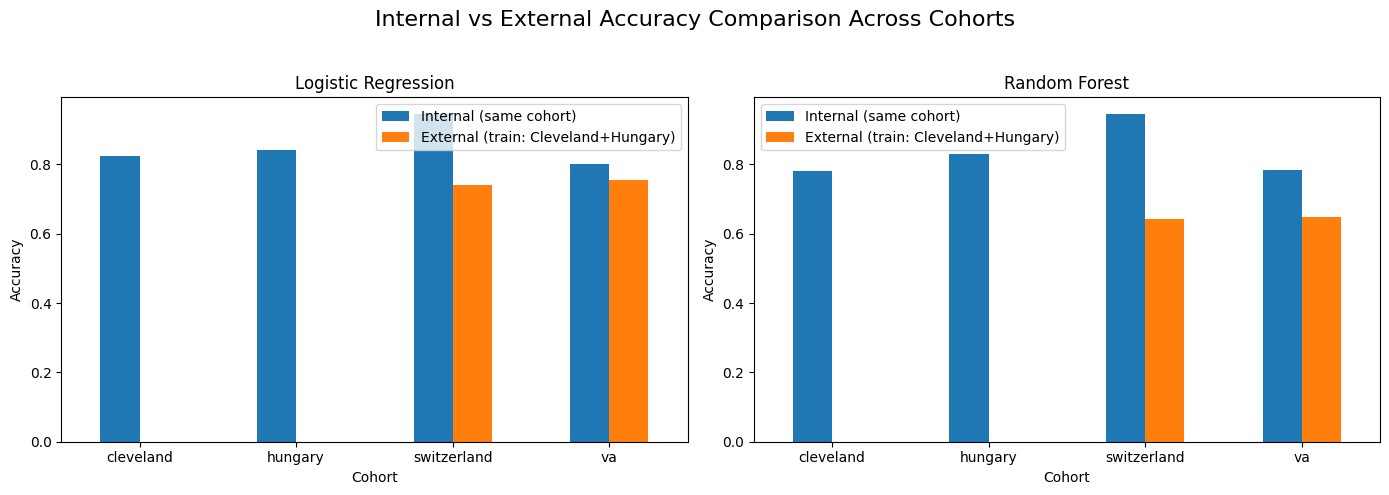

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Get internal accuracies (all cohorts)
logreg_internal_plot = logreg_internal_df[["cohort", "internal_accuracy"]].copy()
rf_internal_plot = rf_internal_df[["cohort", "internal_accuracy"]].copy()

# Get external accuracies (only switzerland & va)
logreg_external_plot = logreg_df[["test_cohort", "accuracy"]].rename(columns={
    "test_cohort": "cohort",
    "accuracy": "external_accuracy"
})

rf_external_plot = rf_df[["test_cohort", "accuracy"]].rename(columns={
    "test_cohort": "cohort",
    "accuracy": "external_accuracy"
})

# Merge (this will leave NaN for Cleveland & Hungary external)
logreg_plot_df = pd.merge(logreg_internal_plot, logreg_external_plot, on="cohort", how="left").set_index("cohort")
rf_plot_df = pd.merge(rf_internal_plot, rf_external_plot, on="cohort", how="left").set_index("cohort")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Logistic Regression
logreg_plot_df.plot(kind="bar", ax=axes[0])
axes[0].set_title("Logistic Regression")
axes[0].set_xlabel("Cohort")
axes[0].set_ylabel("Accuracy")
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(["Internal (same cohort)", "External (train: Cleveland+Hungary)"])

# Random Forest
rf_plot_df.plot(kind="bar", ax=axes[1])
axes[1].set_title("Random Forest")
axes[1].set_xlabel("Cohort")
axes[1].set_ylabel("Accuracy")
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(["Internal (same cohort)", "External (train: Cleveland+Hungary)"])

plt.suptitle("Internal vs External Accuracy Comparison Across Cohorts", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

**What we learn from this graph:**

- Internal validation consistently shows higher accuracy than external validation across all cohorts.
- This indicates that models perform better when trained and tested on the same dataset, and struggle when applied to new populations.
- The performance drop is largest for Switzerland, suggesting strong effects of class imbalance or dataset differences.
- The drop is smaller for VA, indicating more stable generalization.
- Logistic Regression consistently achieves higher accuracy than Random Forest in both internal and external settings.
- The gap between internal and external performance highlights the importance of cross-cohort evaluation.

Overall: Internal validation tends to overestimate model performance, and differences between datasets significantly impact generalization across cohorts.

## Step 13: Results Summary and Visualization

This step presents a summary and visualization of cross-cohort evaluation results.

Tables and visualizations are used to provide a clear comparison of model performance across different training and testing cohorts, highlighting generalization patterns.

### 13.1: Generalization Gap in Accuracy

This graph shows the drop in accuracy from internal to external validation for Switzerland and VA. A larger drop indicates weaker generalization to unseen populations.

This gap reflects reduced generalization ability when applying models to unseen populations.

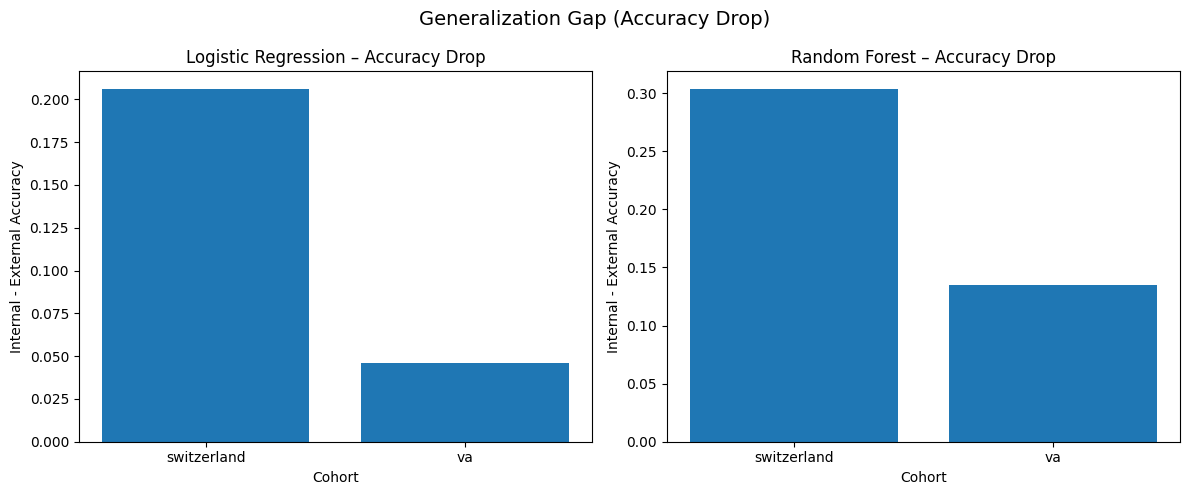

In [ ]:
import matplotlib.pyplot as plt

# Compute drop (internal - external)
logreg_comparison_df["accuracy_drop"] = (
    logreg_comparison_df["internal_accuracy"] - logreg_comparison_df["external_accuracy"]
)

rf_comparison_df["accuracy_drop"] = (
    rf_comparison_df["internal_accuracy"] - rf_comparison_df["external_accuracy"]
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Logistic Regression
axes[0].bar(
    logreg_comparison_df["cohort"],
    logreg_comparison_df["accuracy_drop"]
)
axes[0].set_title("Logistic Regression – Accuracy Drop")
axes[0].set_ylabel("Internal - External Accuracy")
axes[0].set_xlabel("Cohort")

# Random Forest
axes[1].bar(
    rf_comparison_df["cohort"],
    rf_comparison_df["accuracy_drop"]
)
axes[1].set_title("Random Forest – Accuracy Drop")
axes[1].set_ylabel("Internal - External Accuracy")
axes[1].set_xlabel("Cohort")

plt.suptitle("Generalization Gap (Accuracy Drop)", fontsize=14)
plt.tight_layout()
plt.show()

**What we learn from this graph:**

- There is a clear drop in accuracy when moving from internal to external validation.
- This confirms that models perform better when trained and tested on the same cohort.
- The drop is larger for Switzerland, indicating weaker generalization.
- VA shows a smaller drop, suggesting slightly more stable performance across datasets.
- Random Forest shows a larger accuracy drop than Logistic Regression, indicating poorer generalization.

Overall: The accuracy gap highlights that both models struggle to generalize across cohorts, with Logistic Regression being more stable than Random Forest.

### 13.2: Final Logistic Regression Results

Logistic Regression showed strong internal performance across cohorts and more stable external performance than Random Forest during external testing.

In external testing on Switzerland and VA, the model maintained moderate accuracy and relatively strong F1-scores, indicating better cross-cohort stability than Random Forest.

In [ ]:
print("\n================ FINAL LOGISTIC REGRESSION RESULTS ================\n")

print("External Validation Results")
display(logreg_df)

print("\nInternal Validation Results")
display(logreg_internal_df)


================ FINAL LOGISTIC REGRESSION RESULTS ================

External Validation Results


,model,train_cohort,test_cohort,n_train,n_test,accuracy,precision,recall,f1,roc_auc
0,LogisticRegression,cleveland+hungary,switzerland,596,123,0.739837,0.966292,0.747826,0.843137,0.758696
1,LogisticRegression,cleveland+hungary,va,596,199,0.753769,0.861314,0.797297,0.828070,0.757750



Internal Validation Results


,model,cohort,n_total,internal_accuracy,internal_precision,internal_recall,internal_f1,internal_roc_auc
0,LogisticRegression,cleveland,303,0.824176,0.825000,0.785714,0.804878,0.890671
1,LogisticRegression,hungary,293,0.840909,0.800000,0.750000,0.774194,0.925781
2,LogisticRegression,switzerland,123,0.945946,0.945946,1.000000,0.972222,0.557143
3,LogisticRegression,va,199,0.800000,0.800000,0.977778,0.880000,0.765185


**Final Logistic Regression Results:**

- The model performs well within individual cohorts (internal accuracy ≈ 0.80–0.95).
- Performance drops noticeably in external validation but remains more stable than Random Forest
- Switzerland and VA represent the external test cohorts, where performance drops compared to internal validation but remains relatively stable.
- Switzerland has very high internal performance but much lower external performance, suggesting possible overfitting or data differences.
- VA shows slightly more stable external performance compared to Switzerland.
- Precision is generally high, while recall is sometimes lower, indicating missed positive cases.

Overall: Logistic Regression captures patterns within datasets effectively but struggles to generalize across different cohorts.

### 13.3: Final Random Forest Results

Random Forest performed well during internal validation but showed weaker external generalization than Logistic Regression. Its external accuracy and F1-scores were lower on Switzerland and VA, suggesting that the more complex model transferred less effectively across cohorts.

In [ ]:
print("\n================ FINAL RANDOM FOREST RESULTS ================\n")

print("External Validation Results")
display(rf_df)

print("\nInternal Validation Results")
display(rf_internal_df)


================ FINAL RANDOM FOREST RESULTS ================

External Validation Results


,model,train_cohort,test_cohort,n_train,n_test,accuracy,precision,recall,f1,roc_auc
0,RandomForest,cleveland+hungary,switzerland,596,123,0.642276,0.973333,0.634783,0.768421,0.765217
1,RandomForest,cleveland+hungary,va,596,199,0.648241,0.861111,0.628378,0.726562,0.725755



Internal Validation Results


,model,cohort,n_total,internal_accuracy,internal_precision,internal_recall,internal_f1,internal_roc_auc
0,RandomForest,cleveland,303,0.780220,0.761905,0.761905,0.761905,0.878523
1,RandomForest,hungary,293,0.829545,0.742857,0.812500,0.776119,0.915179
2,RandomForest,switzerland,123,0.945946,0.945946,1.000000,0.972222,0.514286
3,RandomForest,va,199,0.783333,0.796296,0.955556,0.868687,0.791852


**Final Random Forest Results:**

- The model performs well internally (accuracy ≈ 0.78–0.95), indicating strong fit to training data.
- External performance drops significantly, confirming poor generalization across cohorts.
- Switzerland and VA are used as external test cohorts, where performance decreases significantly compared to internal validation.
- Switzerland again shows a large gap between internal and external results.
- VA shows relatively better generalization compared to other cohorts.
- Precision is high, but recall is often lower, suggesting missed positive cases.

Overall: Random Forest fits the training data well but does not generalize effectively across cohorts, and overall performs worse than Logistic Regression in cross-cohort validation.

### 13.4: Feature Importance Using Random Forest

This step analyzes feature importance using the Random Forest model to identify which variables have the greatest influence on heart disease prediction in each cohort.

By comparing feature importance across datasets, we can understand how different features contribute to model decisions and whether important predictors remain consistent across populations.

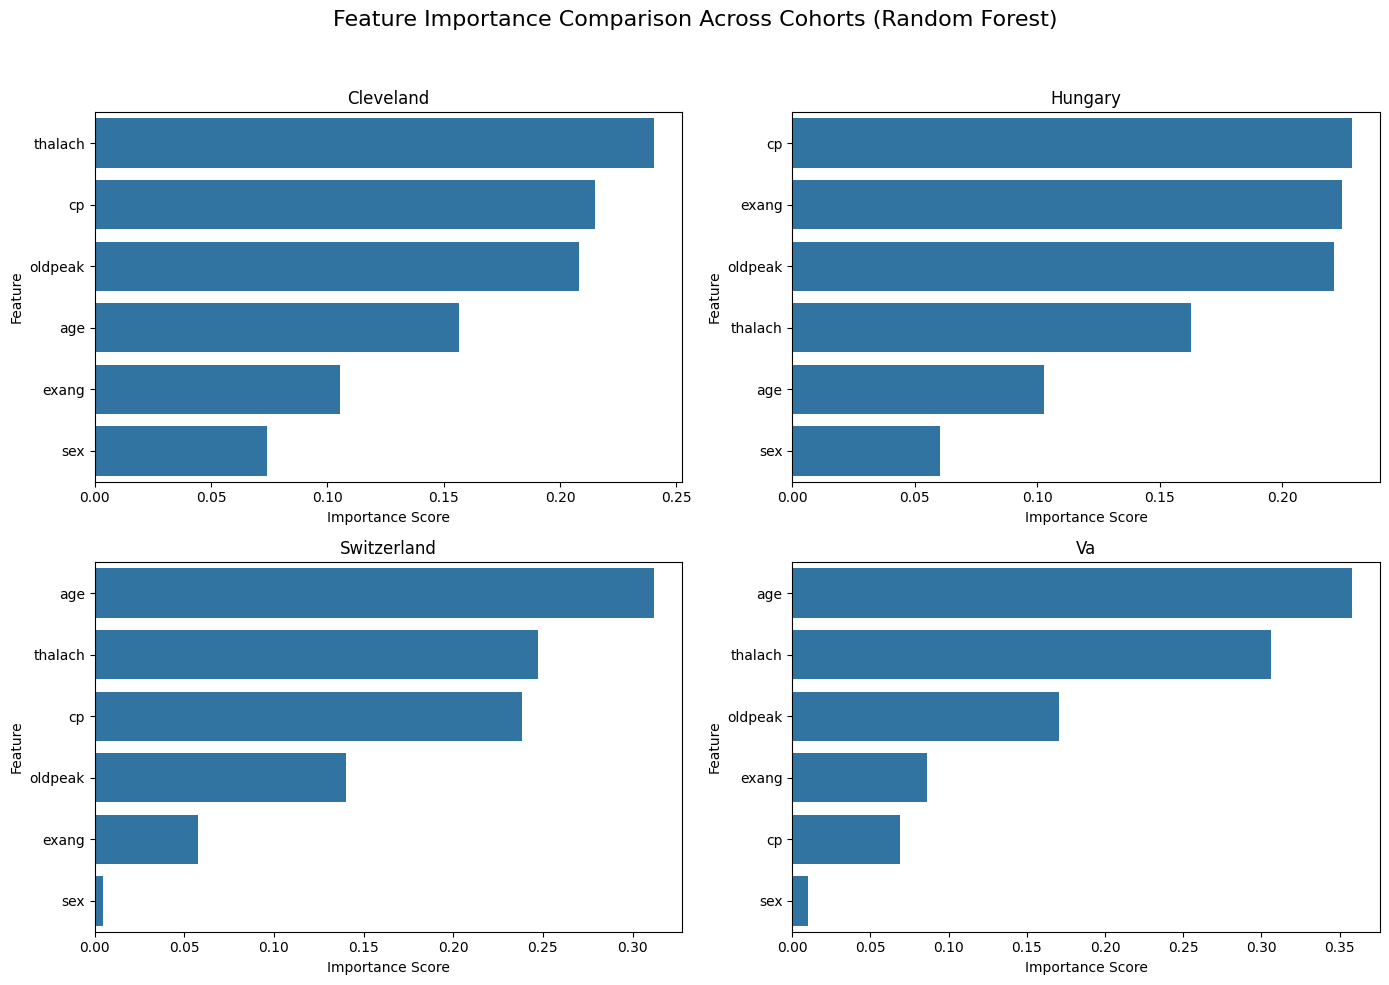

In [ ]:
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

cohorts_list = ["cleveland", "hungary", "switzerland", "va"]

selected_features = ["age", "sex", "cp", "thalach", "exang", "oldpeak"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, cohort in enumerate(cohorts_list):
    df = cleaned_data[cohort][selected_features + ["target_binary"]].dropna().copy()

    X = df[selected_features]
    y = df["target_binary"].astype(int)

    rf = RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42
    )
    rf.fit(X, y)

    importance_df = pd.DataFrame({
        "Feature": X.columns,
        "Importance": rf.feature_importances_
    }).sort_values(by="Importance", ascending=False)

    sns.barplot(
        data=importance_df,
        x="Importance",
        y="Feature",
        ax=axes[i]
    )

    axes[i].set_title(cohort.capitalize())
    axes[i].set_xlabel("Importance Score")
    axes[i].set_ylabel("Feature")

plt.suptitle("Feature Importance Comparison Across Cohorts (Random Forest)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

**What we learn from this graph:**

- **Cleveland:**
  - Most important features: *thalach, oldpeak, age*
  - *cp* contributes but is less influential

- **Hungary:**
  - Most important features: *cp, exang, oldpeak, and thalach*
  - Shows a similar pattern to Cleveland, with slightly more balanced feature contributions

- **Switzerland:**
  - Most important features: *thalach, age, oldpeak*
  - *cp* is less important compared to other cohorts  
  - *sex* and *exang* have minimal impact

- **VA:**
  - Most important features: *age and thalach*, with *oldpeak* also contributing moderately.
  - Other features contribute less, indicating reliance on fewer variables


**Overall:**

- *thalach* is consistently the most important feature across all cohorts  
- *age* and *oldpeak* are also important in most datasets  
- Feature importance varies across cohorts, particularly for *cp* and *exang*  
- Some features, such as *sex*, tend to have lower importance, while the importance of exang varies across cohorts.

**Key insight:**

Differences in feature importance across cohorts indicate that models rely on different patterns in each dataset, which helps explain the drop in performance during cross-cohort validation.

# Conclusion

This project evaluated heart disease prediction across four cohorts from the UCI Heart Disease dataset: Cleveland, Hungary, Switzerland, and VA Long Beach. The Cleveland and Hungary datasets were combined to create a larger and more robust training set, while Switzerland and VA were used for external evaluation. Two models, Logistic Regression and Random Forest, were trained and assessed using both internal validation and external cross-cohort validation.

The results show that both models perform well when evaluated on the same cohort but experience noticeable performance drops when applied to different cohorts. This confirms that internal validation alone can overestimate model performance and does not fully reflect real-world generalization.

Across all experiments, differences between datasets had a greater impact on performance than the choice of model. Logistic Regression consistently achieved better generalization than Random Forest, particularly in external validation, suggesting that simpler models may capture more stable patterns across populations.

The VA cohort demonstrated relatively stable performance across evaluations, while the Switzerland cohort showed inconsistent performance, with very high recall but low ROC-AUC. This suggests potential class imbalance or limited sample size, leading to reduced discriminative ability.

Overall, these findings highlight that building reliable medical prediction models requires diverse and well-balanced data. Improving data quality and representation is more important than increasing model complexity for achieving robust and generalizable performance.